# Steam Hardware Survey

In [1]:
suppressPackageStartupMessages({
library(tidyverse)
library(cowplot)
library(ggrepel)
library(scales)
})
theme_set(theme_cowplot())
options(repr.plot.width=15, repr.plot.height=9)

## Dataset

The data is from the monthy [Steam platform survey](https://store.steampowered.com/hwsurvey/Steam-Hardware-Software-Survey-Welcome-to-Steam)

The dataset used here was compiled by: [jdegene/steamHWsurvey](https://github.com/jdegene/steamHWsurvey), and includes data from 2008 to March 2026.

In [2]:
df <- read_csv('shs.csv', col_types='')
head(df,3)

date,category,name,change,percentage
<date>,<chr>,<chr>,<dbl>,<dbl>
2008-11-01,AMD CPU Speeds,1.4 Ghz to 1.49 Ghz,-0.0004,0.0036
2008-11-01,AMD CPU Speeds,1.5 Ghz to 1.69 Ghz,-0.0025,0.0224
2008-11-01,AMD CPU Speeds,1.7 Ghz to 1.99 Ghz,-0.0024,0.0714


In [3]:
df_plat = read_csv('shs_platform.csv', col_types='')
head(df_plat,3)

date,platform,category,name,change,percentage
<date>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2010-05-01,mac,Free Hard Drive Space (Mac),10 GB to 99 GB,0.3755,0.3755
2010-05-01,mac,Free Hard Drive Space (Mac),100 GB to 249 GB,0.2905,0.2905
2010-05-01,mac,Free Hard Drive Space (Mac),250 GB to 499 GB,0.1576,0.1576


## CPU

### Processor vendor

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 566 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


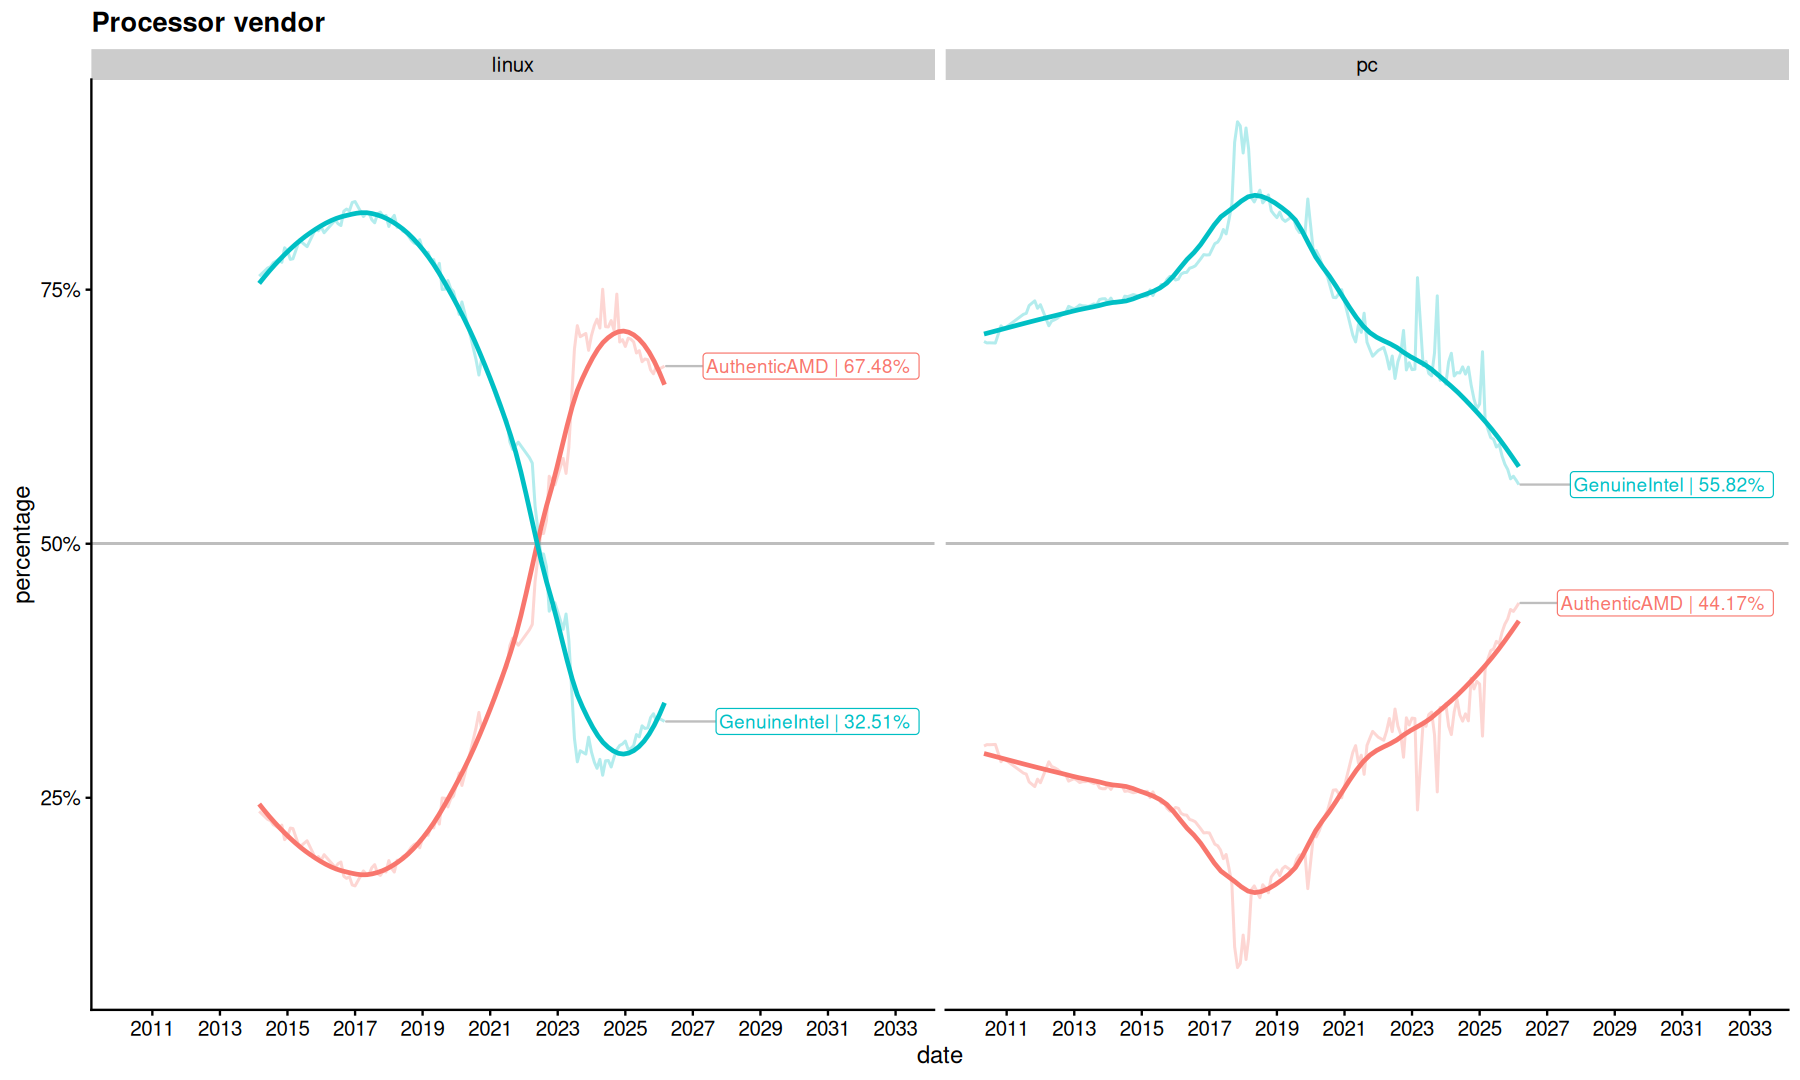

In [4]:
filter(df_plat, grepl('Proc', category)) |>
filter(platform %in% c('pc','linux')) |>
filter(grepl('GenuineIntel|AuthenticAMD', name)) |>
mutate(
    label=ifelse(date==max(date, na.rm=T), sprintf("%s | %.4g%%",name,percentage*100), NA)
) |>
ggplot(aes(x=date, y=percentage, color=name)) +
geom_hline(yintercept=0.5, color='gray') +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
scale_y_continuous(labels=percent_format()) +
geom_label_repel(aes(label=label), hjust='left', direction = 'y', nudge_x=2.5e3, segment.color='gray') +
guides(color='none') +
scale_x_date(date_breaks='2 years', date_labels = '%Y') +
labs(title='Processor vendor') +
facet_wrap(~platform, ncol=2)

The data is separated by platform, "pc" here is Windows systems.

`geom_smooth()` using formula = 'y ~ x'


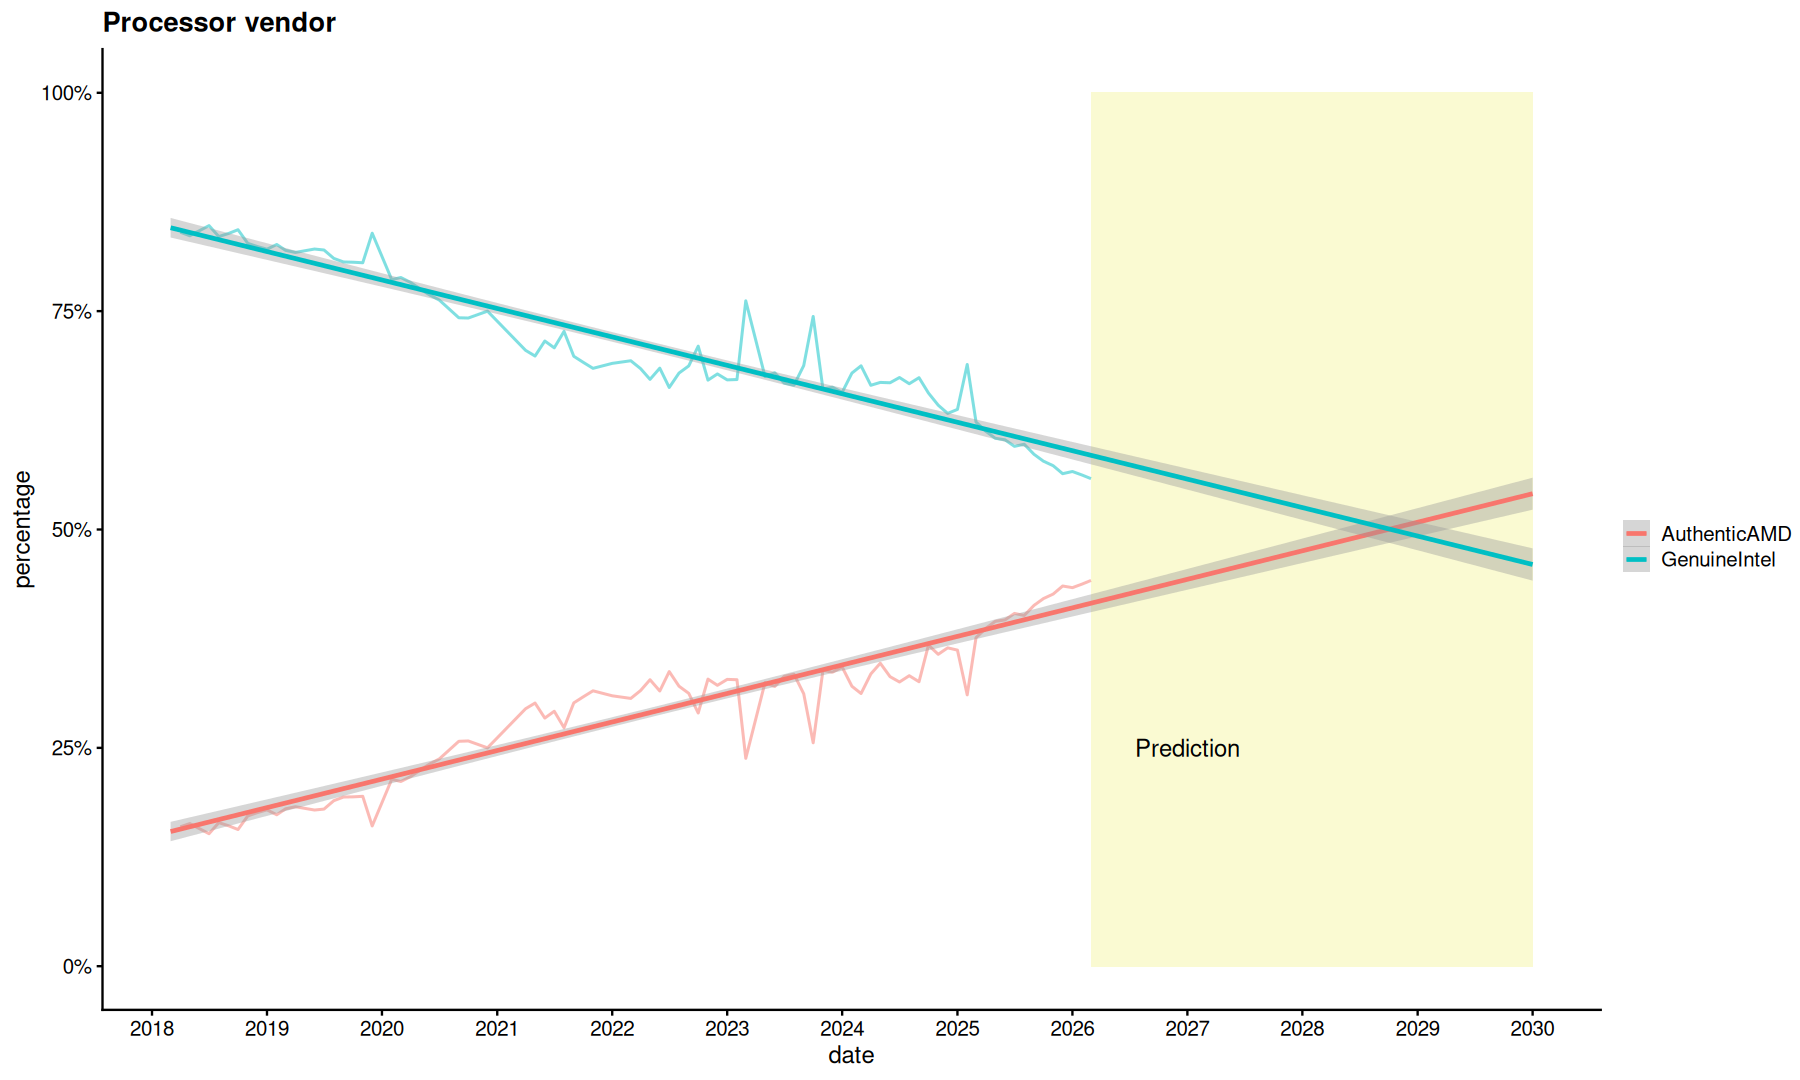

In [5]:
filter(df_plat, grepl('Proc', category)) |>
filter(platform=='pc', date>ymd('2018-03-01')) |>
filter(grepl('GenuineIntel|AuthenticAMD', name)) |>
ggplot(aes(x=date, y=percentage, color=name)) +
geom_rect(aes(ymin=0, ymax=1, xmin=ymd('2026-03-01'), xmax=ymd('2030-01-01')), fill='#FAFAD2',alpha=1, color=NA) +
annotate(geom='text', x=ymd('2027-01-01'), y=0.25, label='Prediction') +
geom_line(alpha=0.5) +
geom_smooth(method='lm', fullrange=TRUE, linewidth=1) +
labs(title='Processor vendor', color='') +
scale_y_continuous(labels=percent_format()) +
scale_x_date(limits=c(ymd('2018-03-01'), ymd('2030-01-01')), date_breaks = '1 years', date_labels = '%Y')

The regression line suggests AMD will overtake by 2029 if the trend continues.

Since Nov-2025, the mac platform does not sum to 100%, it probably is not counting Apple M-series processors properly:

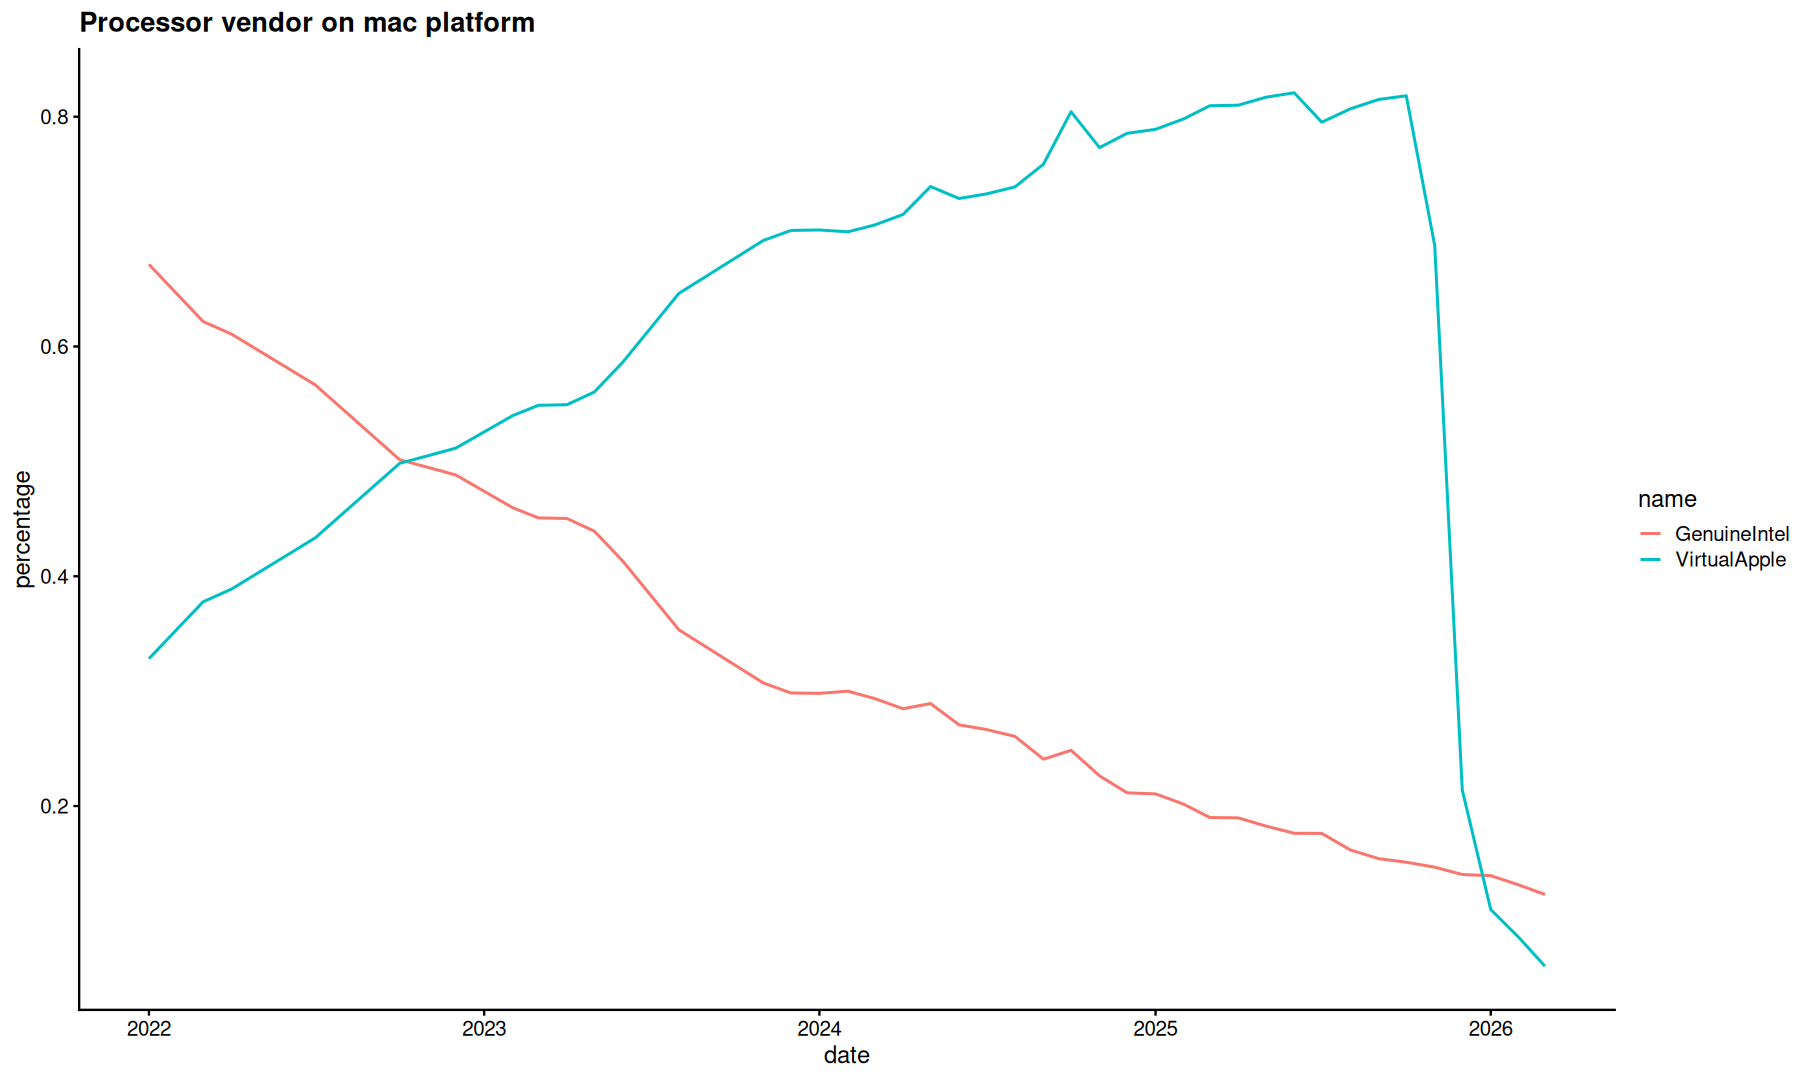

In [6]:
filter(df_plat, grepl('Proc', category), platform=='mac') |>
ggplot(aes(x=date, y=percentage, color=name)) +
geom_line() +
labs(title='Processor vendor on mac platform')

In [7]:
filter(df_plat, grepl('Proc', category)) |>
slice_max(date, n=1) |>
arrange(platform, -percentage)

date,platform,category,name,change,percentage
<date>,<chr>,<chr>,<chr>,<dbl>,<dbl>
2026-03-01,linux,Processor Vendor (Linux),AuthenticAMD,0.002153412,0.6748
2026-03-01,linux,Processor Vendor (Linux),GenuineIntel,-0.004592774,0.3251
2026-03-01,mac,Processor Vendor (OSX),GenuineIntel,-0.062500000,0.1230
2026-03-01,mac,Processor Vendor (OSX),VirtualApple,-0.289149560,0.0606
2026-03-01,pc,Processor Vendor (Windows),GenuineIntel,-0.007291481,0.5582
2026-03-01,pc,Processor Vendor (Windows),AuthenticAMD,0.009484630,0.4417
2026-03-01,pc,Processor Vendor (Windows),MicrosoftXTA,-1.000000000,0.0000


### Number of cpus

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 1369 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


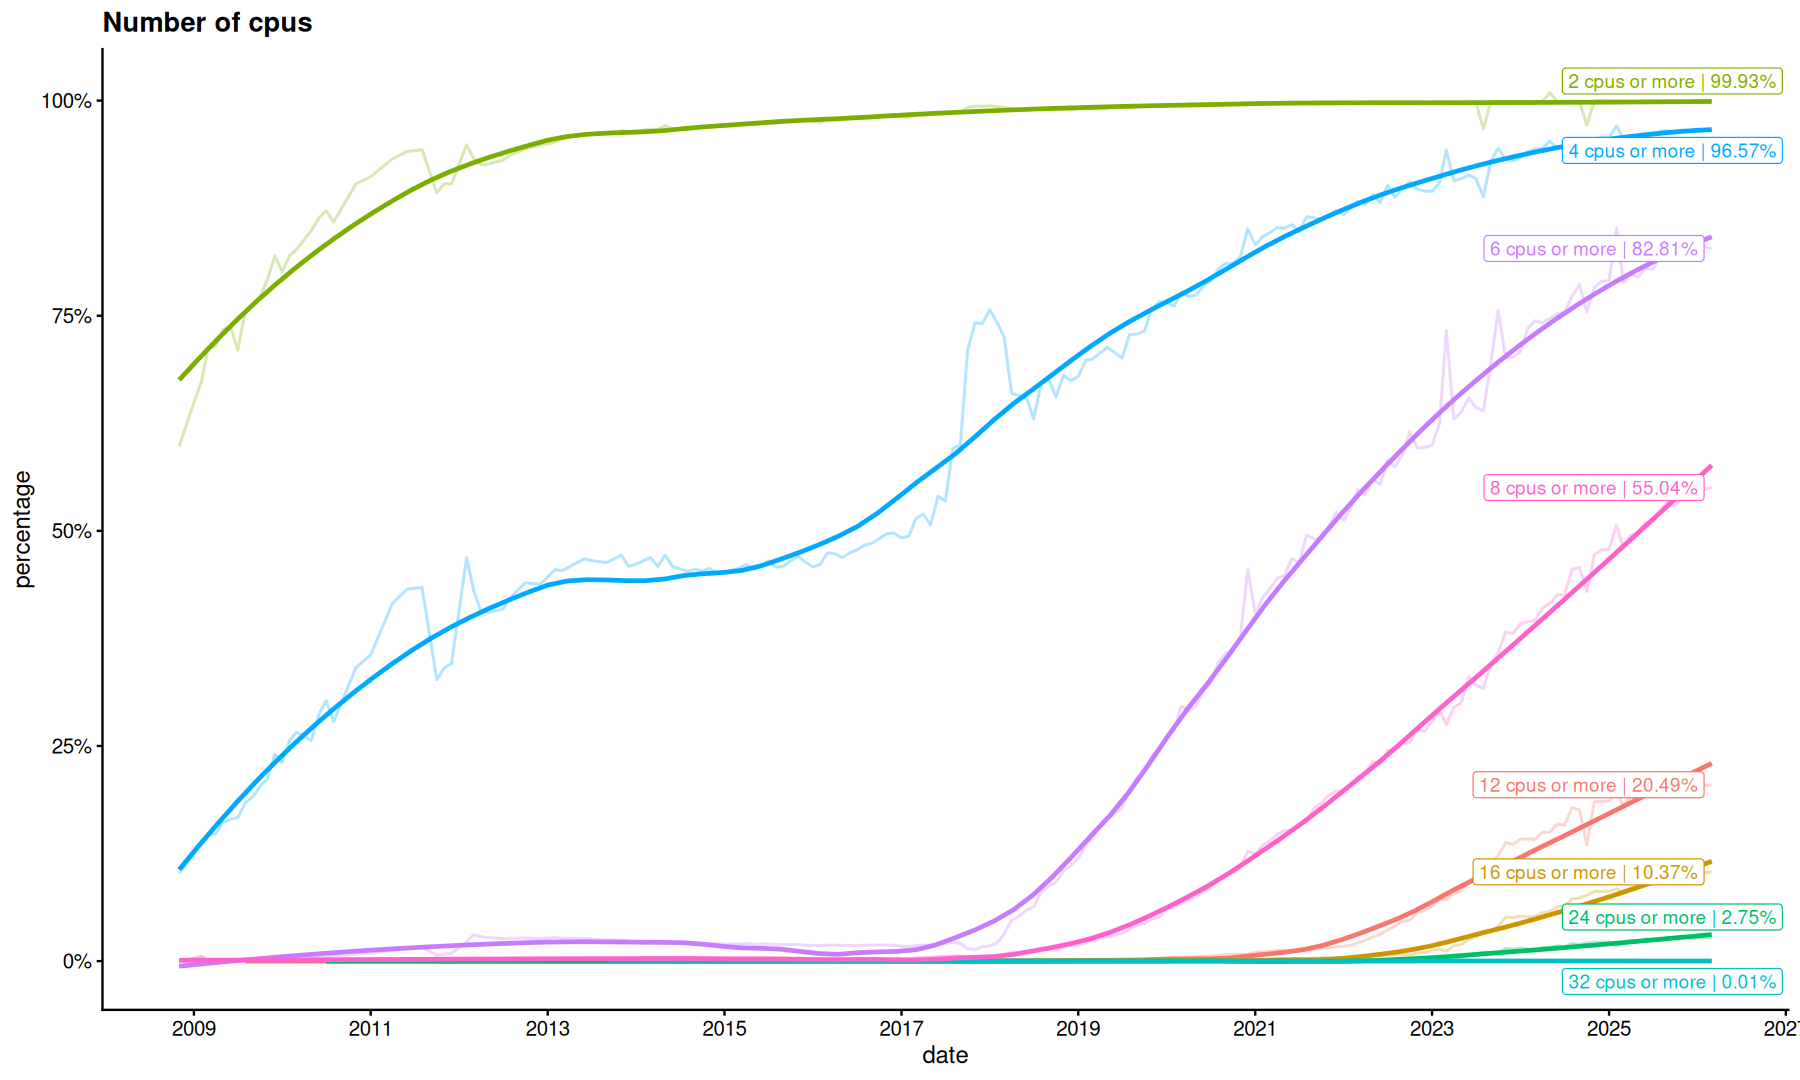

In [8]:
map_df(c(2, 4, 6, 8, 12, 16, 24, 32), function(target_p) {
    filter(df, grepl('Physical CPUs', category)) |>
    mutate(n_cpus = as.numeric(str_extract(name, '(\\d+)', group=1))) |>
    filter(!is.na(n_cpus), n_cpus >= target_p) |>
    distinct(date, percentage) |>
    mutate(label=paste(target_p, 'cpus or more')) 
}) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, label)
) |>
mutate(
    label2=ifelse(date==max(date, na.rm=T), sprintf("%s | %.4g%%",label,percentage*100), NA)
) |>
ggplot(aes(x=date, y=percentage, color=label)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
scale_y_continuous(labels=percent_format()) +
scale_x_date(date_breaks='2 years', date_labels = '%Y') +
geom_label_repel(aes(label=label2)) +
labs(title='Number of cpus') +
guides(color='none')

### Intel CPU Speeds

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 1317 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


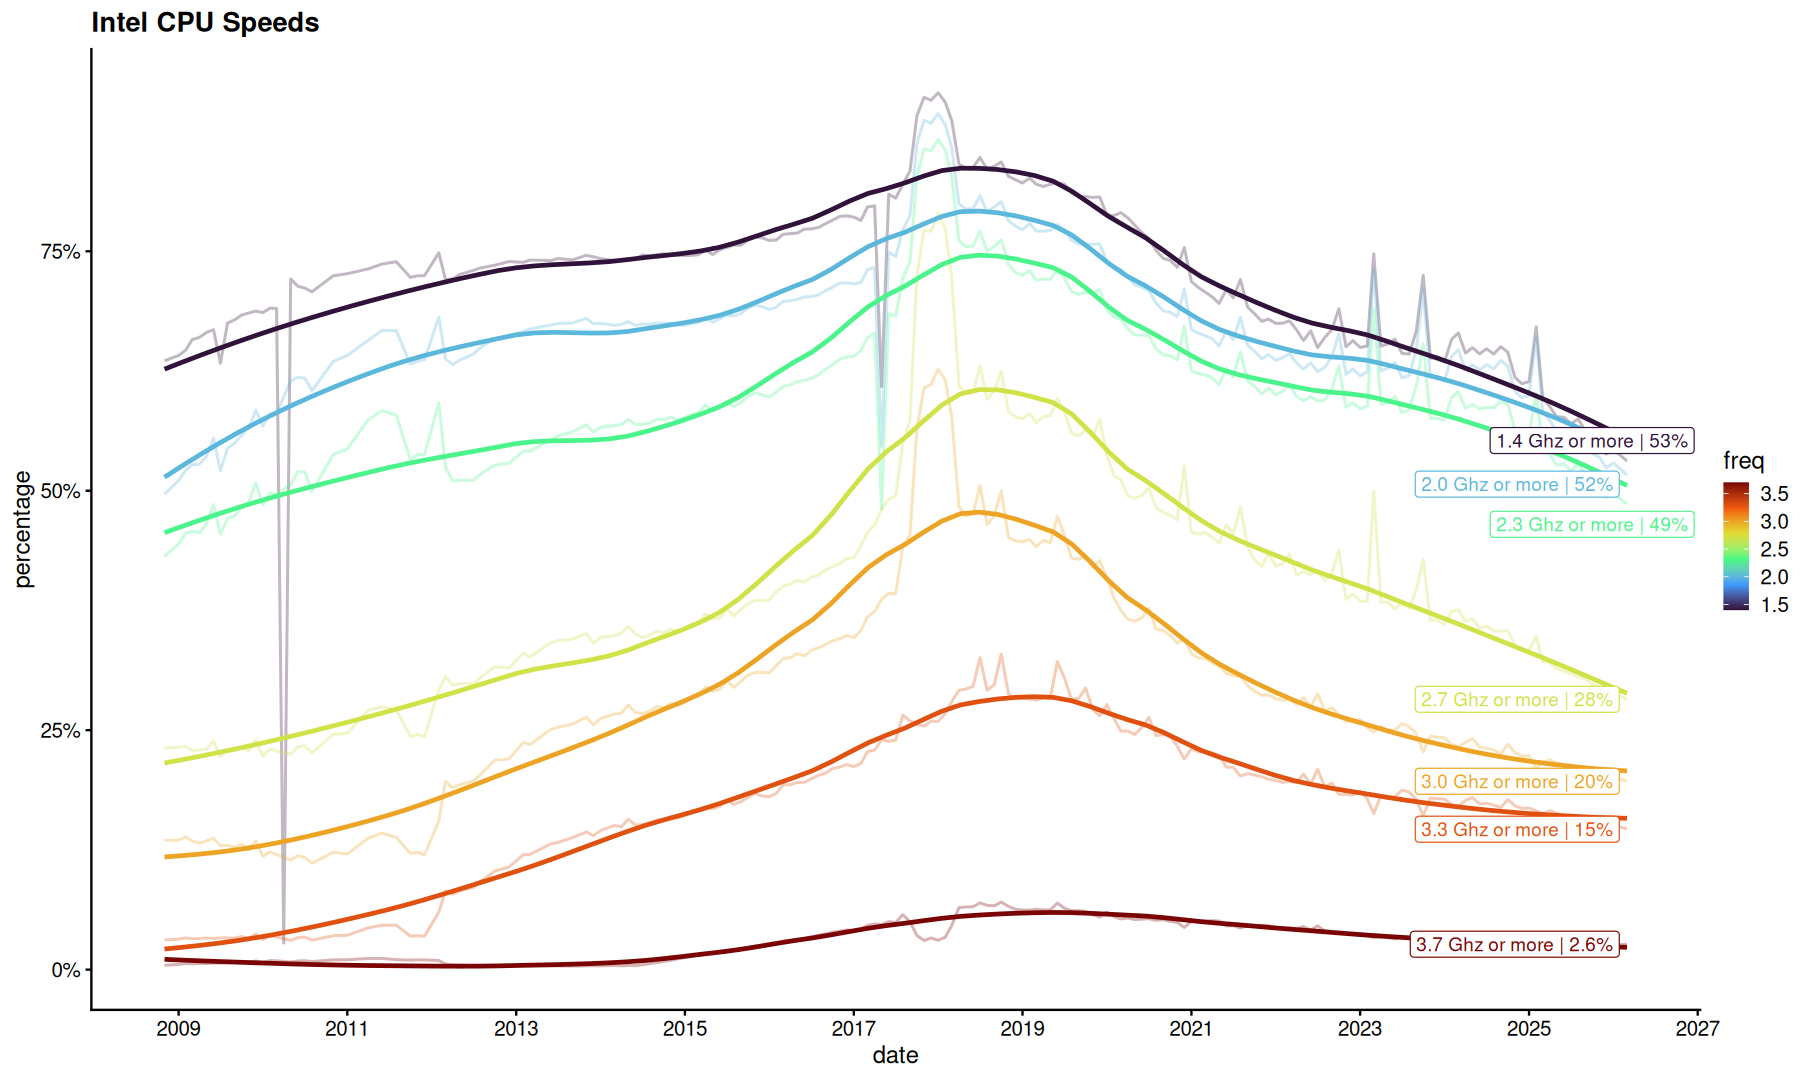

In [9]:
map_df(c(1.4, 2.0, 2.3, 2.7, 3, 3.3, 3.7), function(target_f) {
    filter(df, category == 'Intel CPU Speeds') |>
    mutate(
        f0 = case_when(
            grepl('^\\S+ Ghz to', name) ~ str_extract(name, '^(\\S+) Ghz to', group=1),
            grepl('\\S+ Ghz and above', name) ~ str_extract(name, '(\\S+) Ghz', group=1),
            TRUE ~ NA
        )
    ) |>
    filter(f0 >= target_f) |>
    distinct(date, percentage) |>
    mutate(freq=target_f)
}) |>
summarize(
    percentage=sum(percentage),
    .by =c(date, freq)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%.1f Ghz or more | %.2g%%', freq, percentage*100), NA)) |>
ggplot(aes(x=date, y=percentage, color=freq, group=freq)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label)) +
scale_y_continuous(labels=percent_format()) +
labs(title='Intel CPU Speeds') +
scale_color_viridis_c(option='turbo') +
scale_x_date(date_breaks='2 years', date_labels ='%Y')

It is unclear how this data is collected, but it is probabaly base cpu frequency.

You can see that cpu frequency starts decreasing in 2019, around the same time that cpu core amount increases.

## System RAM

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 784 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


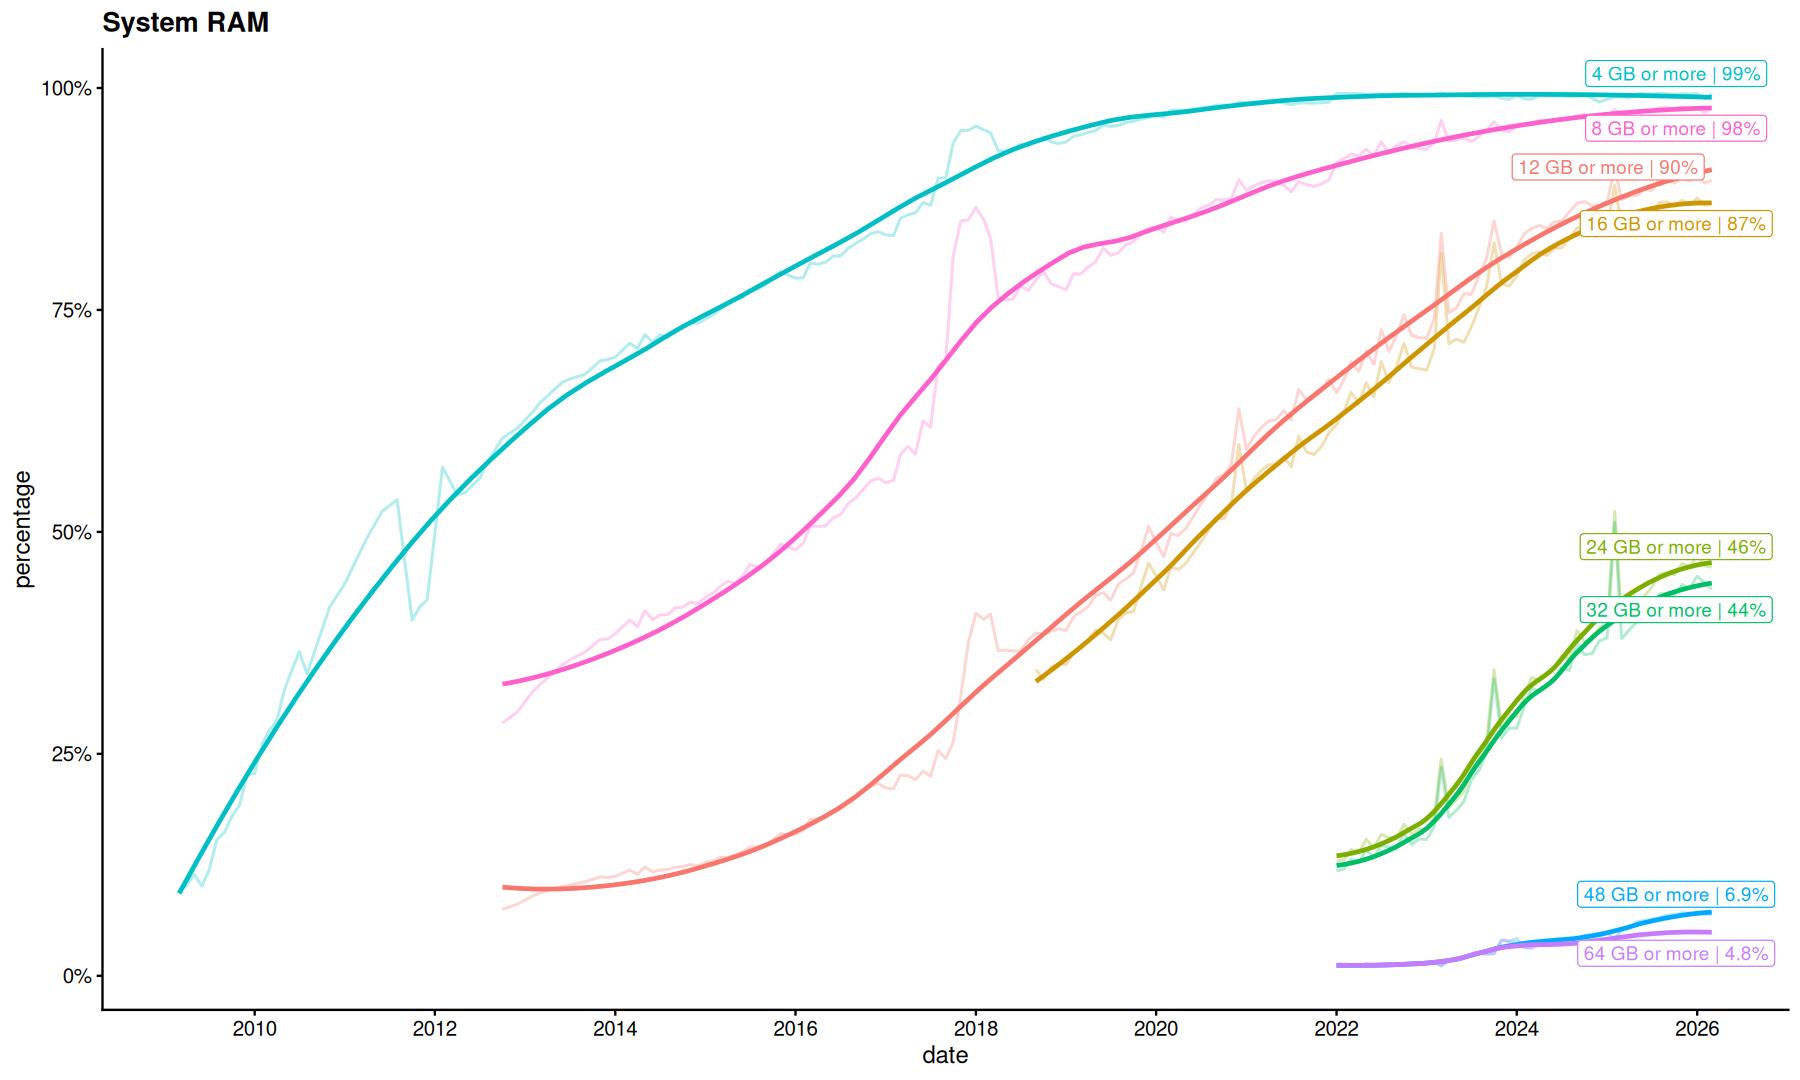

In [10]:
map_df(c(4, 8, 12, 16, 24, 32, 48, 64), function(target_p) {
    filter(df, category=='System RAM') |>
    mutate(
        val=as.numeric(str_extract(name, '(\\S+) [MG]B', group=1)),
        unit=str_extract(name, '([MG]B)', group=1),
    ) |>
    filter(val >= target_p, unit == 'GB') |>
    summarize(
        percentage=sum(percentage),
        .by=date
    ) |>
    mutate(label=paste(target_p,'GB or more'))
}) |>
mutate(label2=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',label,100*percentage), NA), .by=label) |>
ggplot(aes(x=date, y=percentage, color=label)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label2)) +
guides(color='none') +
labs(title='System RAM') +
scale_x_date(date_breaks = '2 years', date_labels = '%Y') +
scale_y_continuous(label=percent_format())

## Graphics Card

### VRAM

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


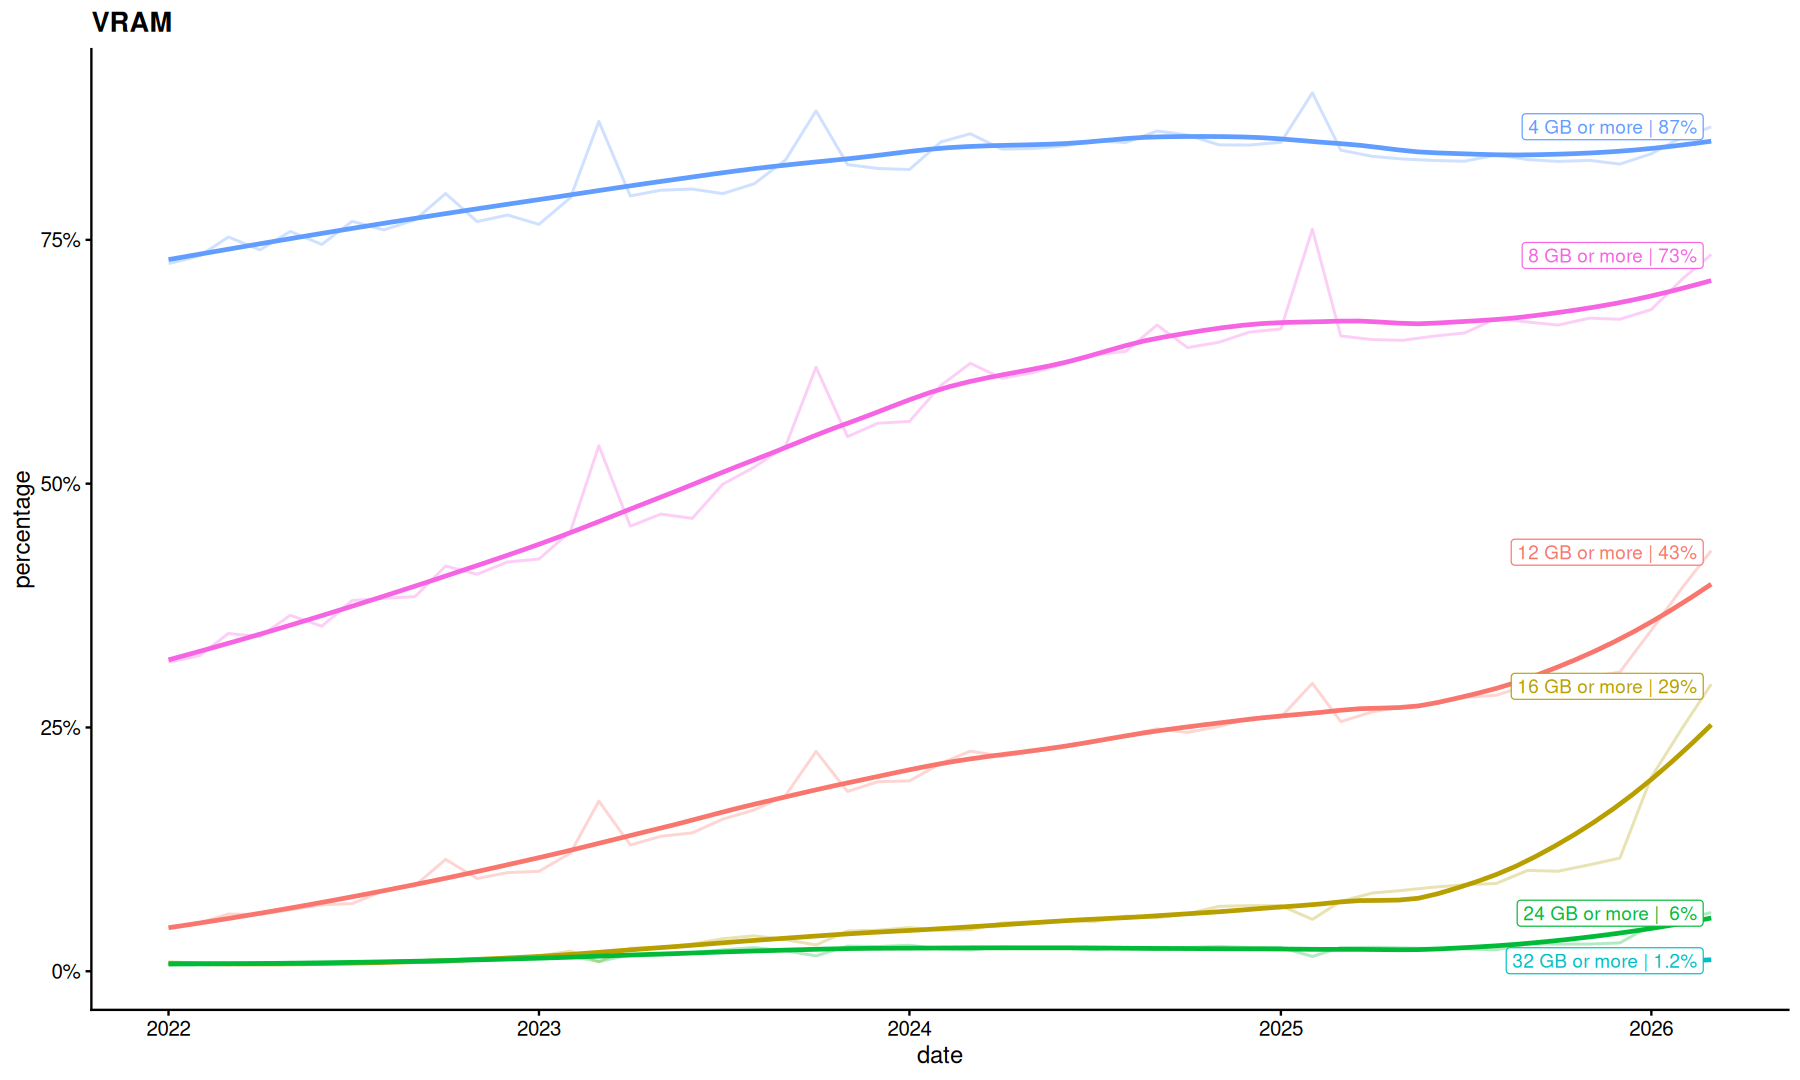

In [11]:
map_df(c(4, 8, 12, 16, 24, 32), function(target_p) {
    filter(df, category=='VRAM') |>
    mutate(
        val=as.numeric(str_extract(name, '(\\S+) [MG]B', group=1)),
        unit=str_extract(name, '([MG]B)', group=1),
    ) |>
    filter(val >= target_p, unit == 'GB') |>
    summarize(
        percentage=sum(percentage),
        .by=date
    ) |>
    mutate(label=paste(target_p,'GB or more'))
}) |>
mutate(label2=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',label,100*percentage), NA), .by=label) |>
ggplot(aes(x=date, y=percentage, color=label)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label2)) +
guides(color='none') +
labs(title='VRAM') +
scale_x_date(date_breaks = '1 years', date_labels = '%Y') +
scale_y_continuous(label=percent_format()) -> p
suppressWarnings(print(p))

### Video Card Vendor

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 692 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


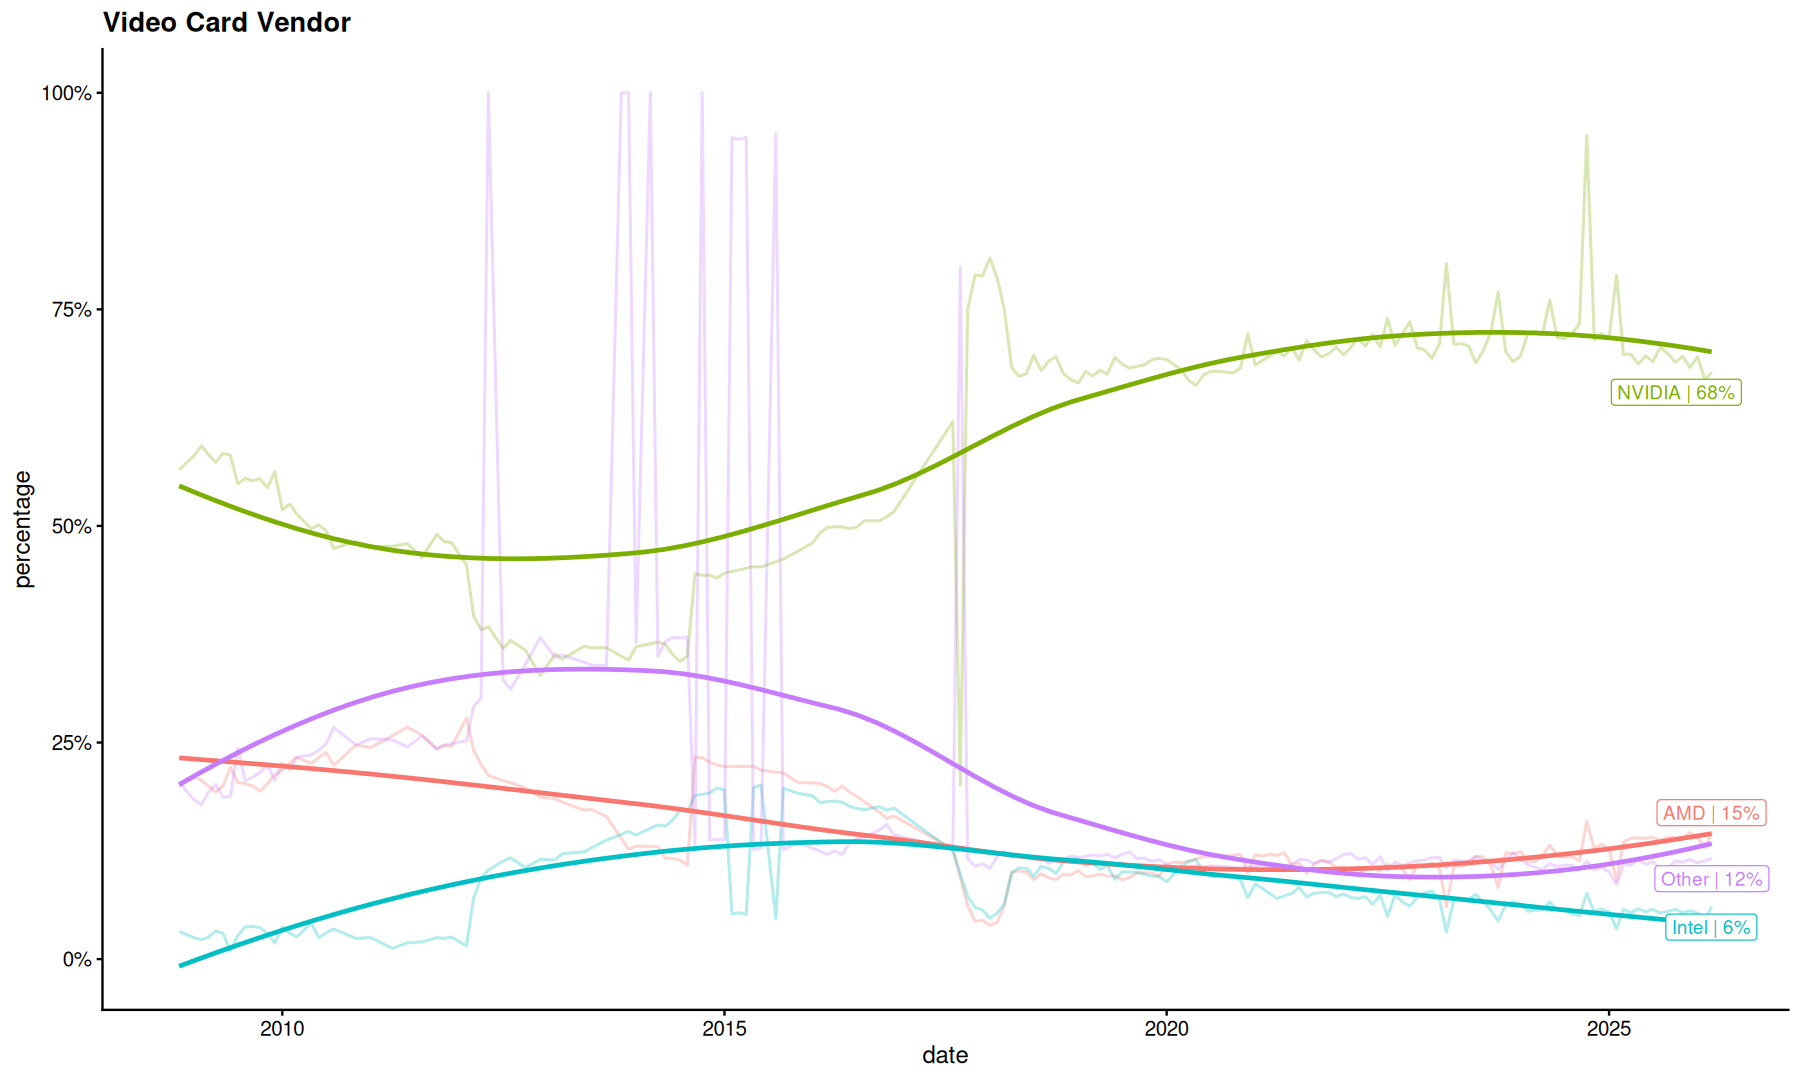

In [12]:
filter(df, grepl('Video Card Desc', category)) |>
mutate(
    vendor=case_when(
        grepl('AMD|Radeon|ATI', name) ~ 'AMD',
        grepl('Intel|Haswell', name) ~ 'Intel',
        grepl('NVIDIA', name) ~ 'NVIDIA',
        TRUE ~ 'Other'
    ),
    vendor = factor(vendor, levels=c('AMD','NVIDIA','Intel','Other'))
) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, vendor)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %.2g%%', vendor, percentage*100), NA)) |>
ggplot(aes(x=date, y=percentage, color=vendor)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=1, linewidth=1) +
guides(color='none') +
labs(title='Video Card Vendor') +
scale_y_continuous(label=percent_format()) +
geom_label_repel(aes(label=label), max.overlaps = Inf) 

### Video Card Models

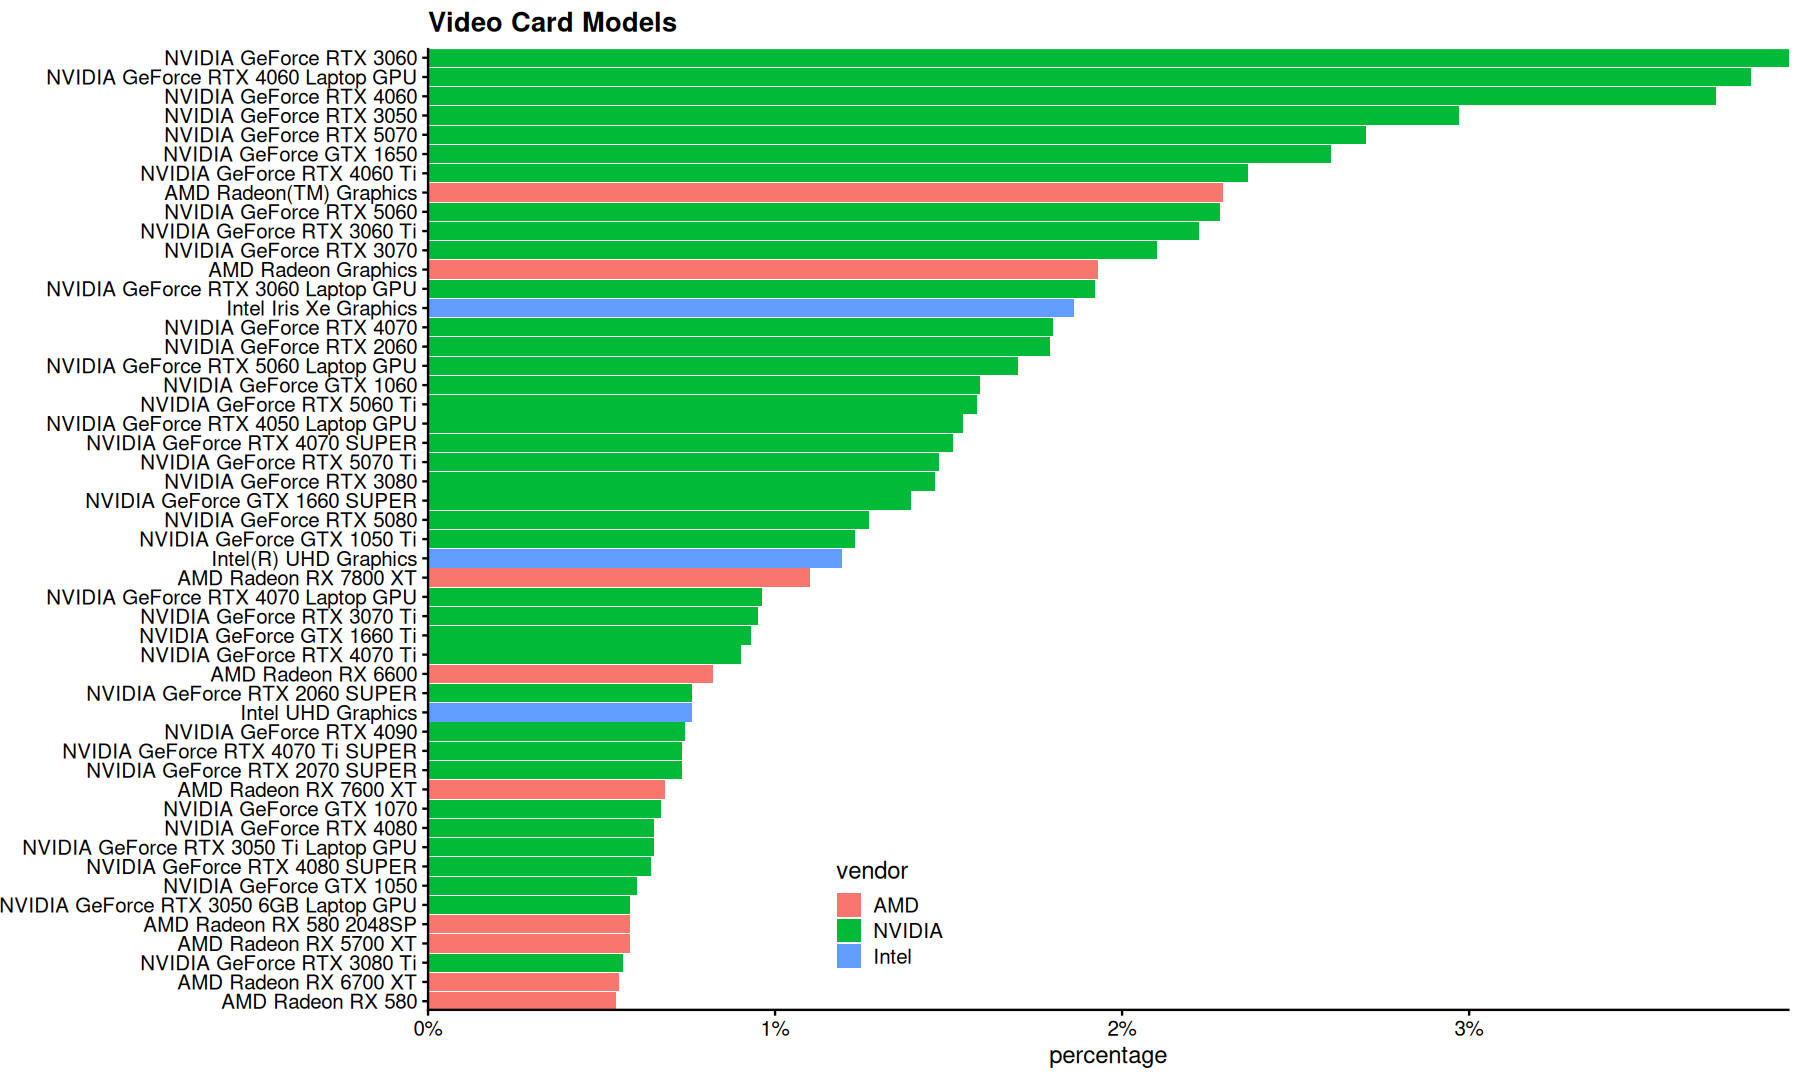

In [13]:
filter(df, grepl('Video Card Desc', category)) |>
filter(date==max(date)) |>
mutate(
    name = ifelse(is.na(name), 'Other', name),
    vendor=case_when(
        grepl('AMD|Radeon|ATI', name) ~ 'AMD',
        grepl('Intel|Haswell', name) ~ 'Intel',
        grepl('NVIDIA', name) ~ 'NVIDIA',
        TRUE ~ 'Other'
    ),
    vendor = factor(vendor, levels=c('AMD','NVIDIA','Intel','Other'))
) |>
summarize(
    percentage=sum(percentage),
    .by = c(vendor, name)
) |>
filter(vendor != 'Other') |>
top_n(percentage, n=50) |>
ggplot(aes(y=fct_reorder(name, percentage), x=percentage, fill=vendor)) +
geom_col() +
theme(legend.position = 'inside', legend.position.inside = c(0.3, 0.1)) +
coord_cartesian(expand=0) +
labs(title='Video Card Models',y=NULL) +
scale_x_continuous(labels=percent_format())

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 138 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


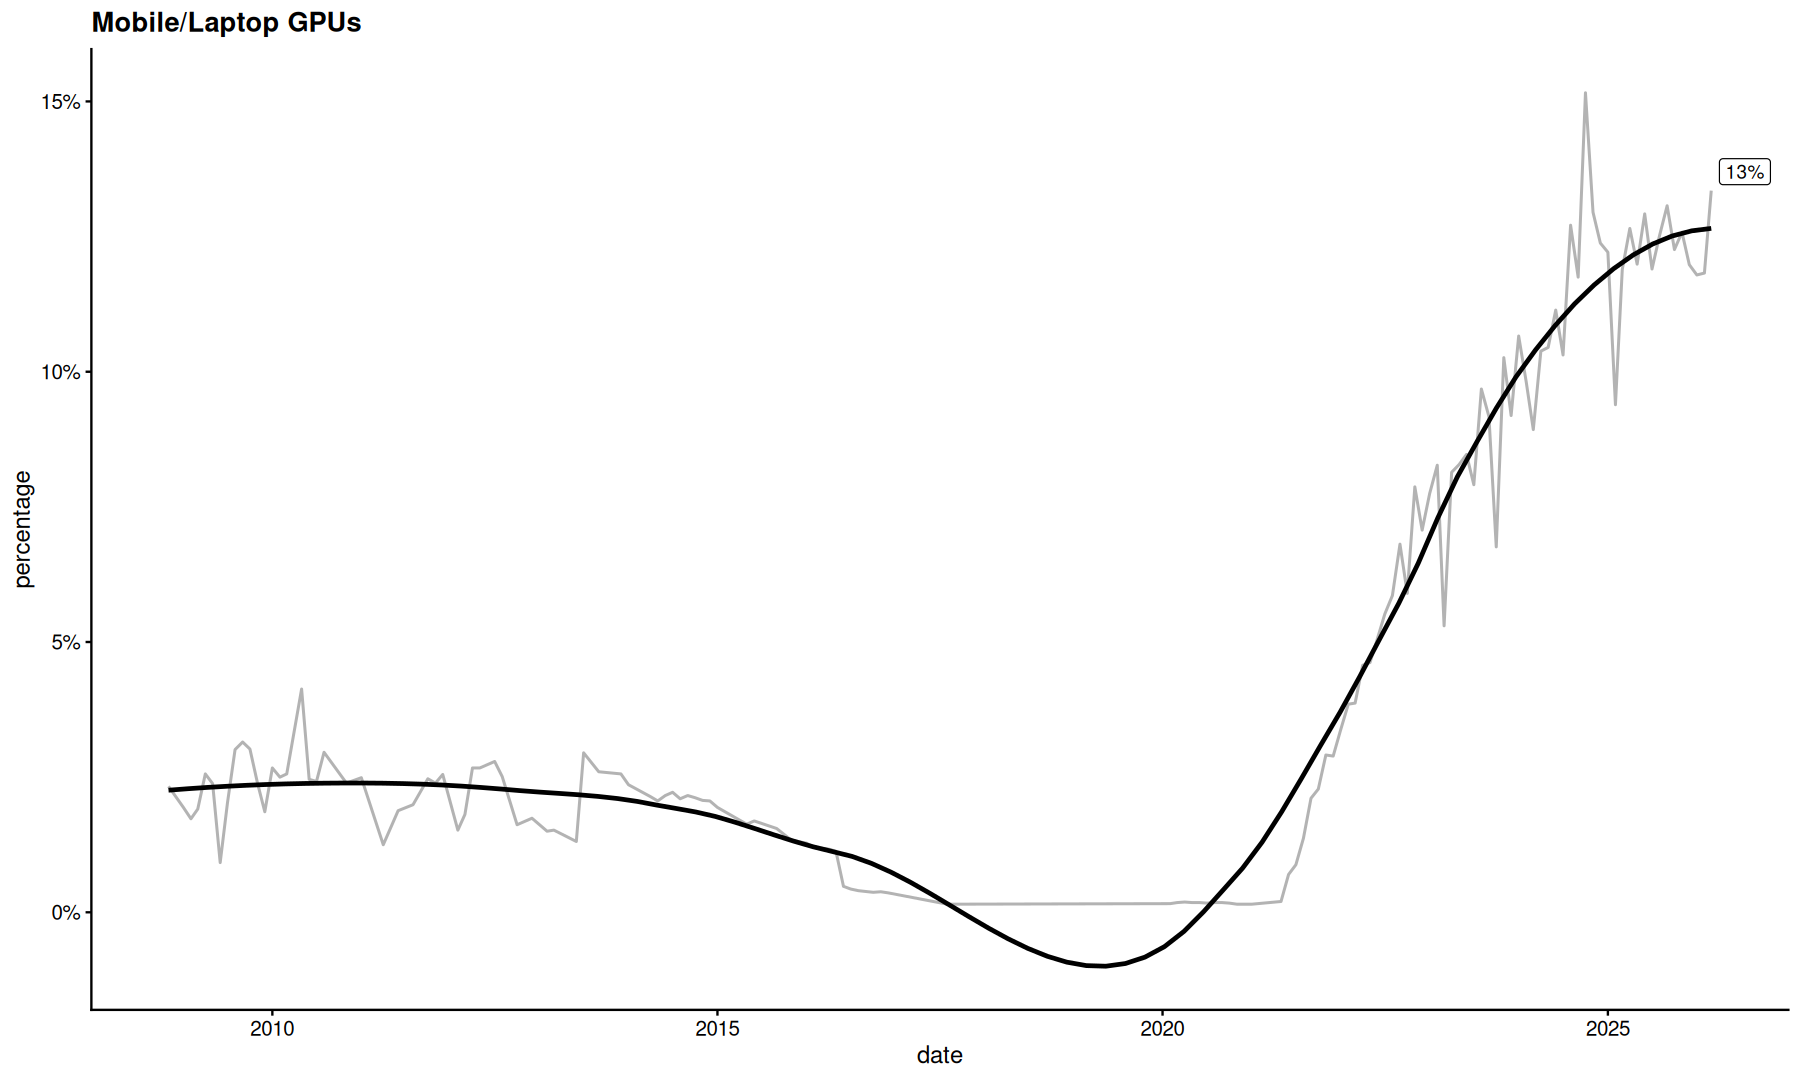

In [14]:
filter(df, grepl('Video Card Desc', category)) |>
filter(grepl('Mobile|Laptop', name)) |>
summarize(
    percentage=sum(percentage),
    .by = c(date)
) |>
mutate(label=ifelse(date==max(date), sprintf('%.2g%%', percentage*100), NA)) |>
ggplot(aes(x=date, y=percentage)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1, color='black') +
geom_label_repel(aes(label=label)) +
labs(title='Mobile/Laptop GPUs') +
scale_y_continuous(label=percent_format())

This is an approximation, because some models don't have a distinct name for the mobile version.

## Operating System

Note that the survey page does not list "Other" distros, so its necessary to merge data from the platform table to properly account for this, I'm using the same code as in https://github.com/jdegene/steamHWsurvey/blob/68066407f287b497d08c3466ea4e7f5d073efc8f/create_readme.py#L1023

In [15]:
linux_v_list <- filter(df_plat, category=='Linux Version', name != 'Other') |> with(unique(name))
os_df <- 
    filter(df, category=='OS Version') |>
    mutate(
        OS = case_when(
            grepl('Windows', name) ~ 'Windows',
            grepl('MacOS', name) ~ 'MacOS',
            name %in% linux_v_list ~ 'Linux',
            TRUE ~ 'Other'
    ))

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


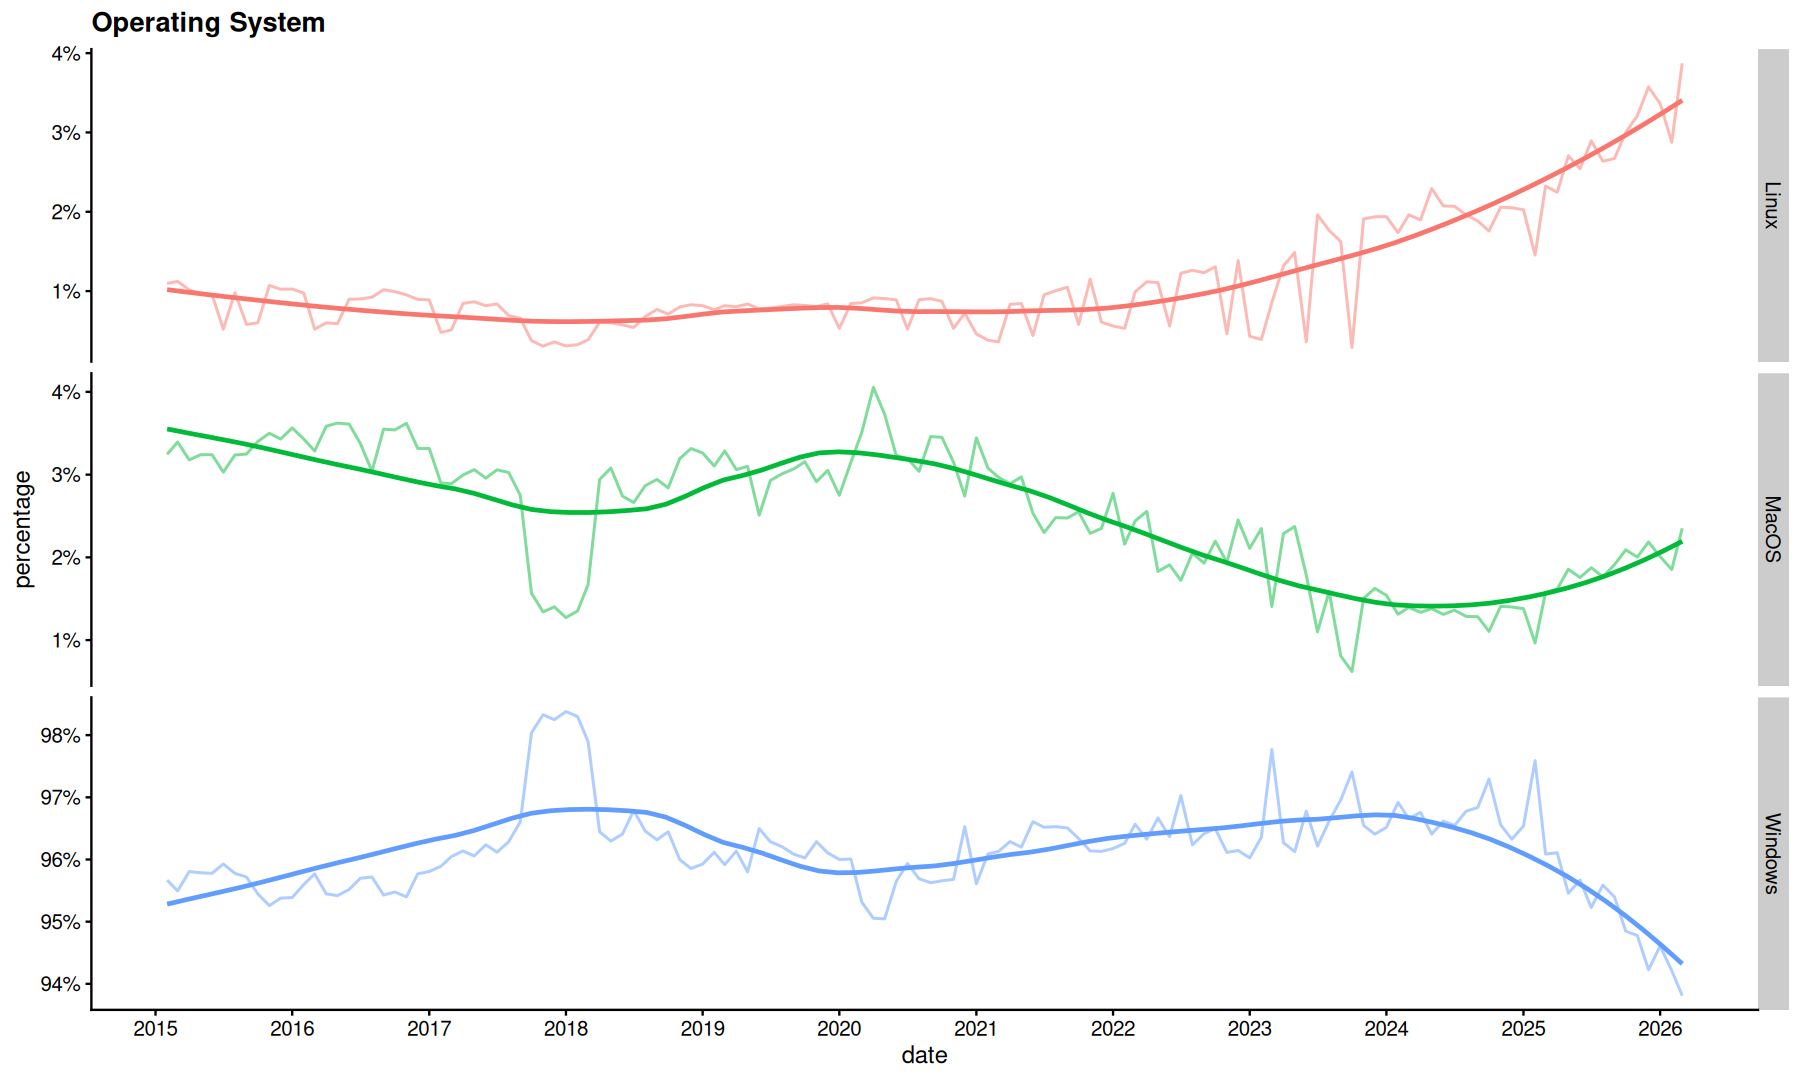

In [16]:
filter(df_plat, grepl("Version", category)) |>
rename(percentage_plat=percentage) |>
right_join(os_df, by=c('date','name')) |>
mutate(change.x=NULL,change.y=NULL) |>
mutate(
    corr_fac = 1/sum(percentage_plat),
    .by=c('OS','date')
) |>
mutate(
    corr_fac=replace_na(corr_fac, 1),
    p2 = percentage * corr_fac
) |>
summarize(
    percentage=sum(p2),
    .by=c(date, OS)
) |>
filter(date>ymd('2015-01-01')) |>
ggplot(aes(x=date, y=percentage, color=OS)) +
geom_line(alpha=0.5) +
geom_smooth(se=F, span=0.5, linewidth=1) +
facet_grid(OS~., scales='free_y') +
scale_x_date(date_breaks = '1 years', date_labels = '%Y') +
scale_y_continuous(labels=scales::percent_format()) +
labs(title='Operating System') +
guides(color='none')

### Linux distros

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


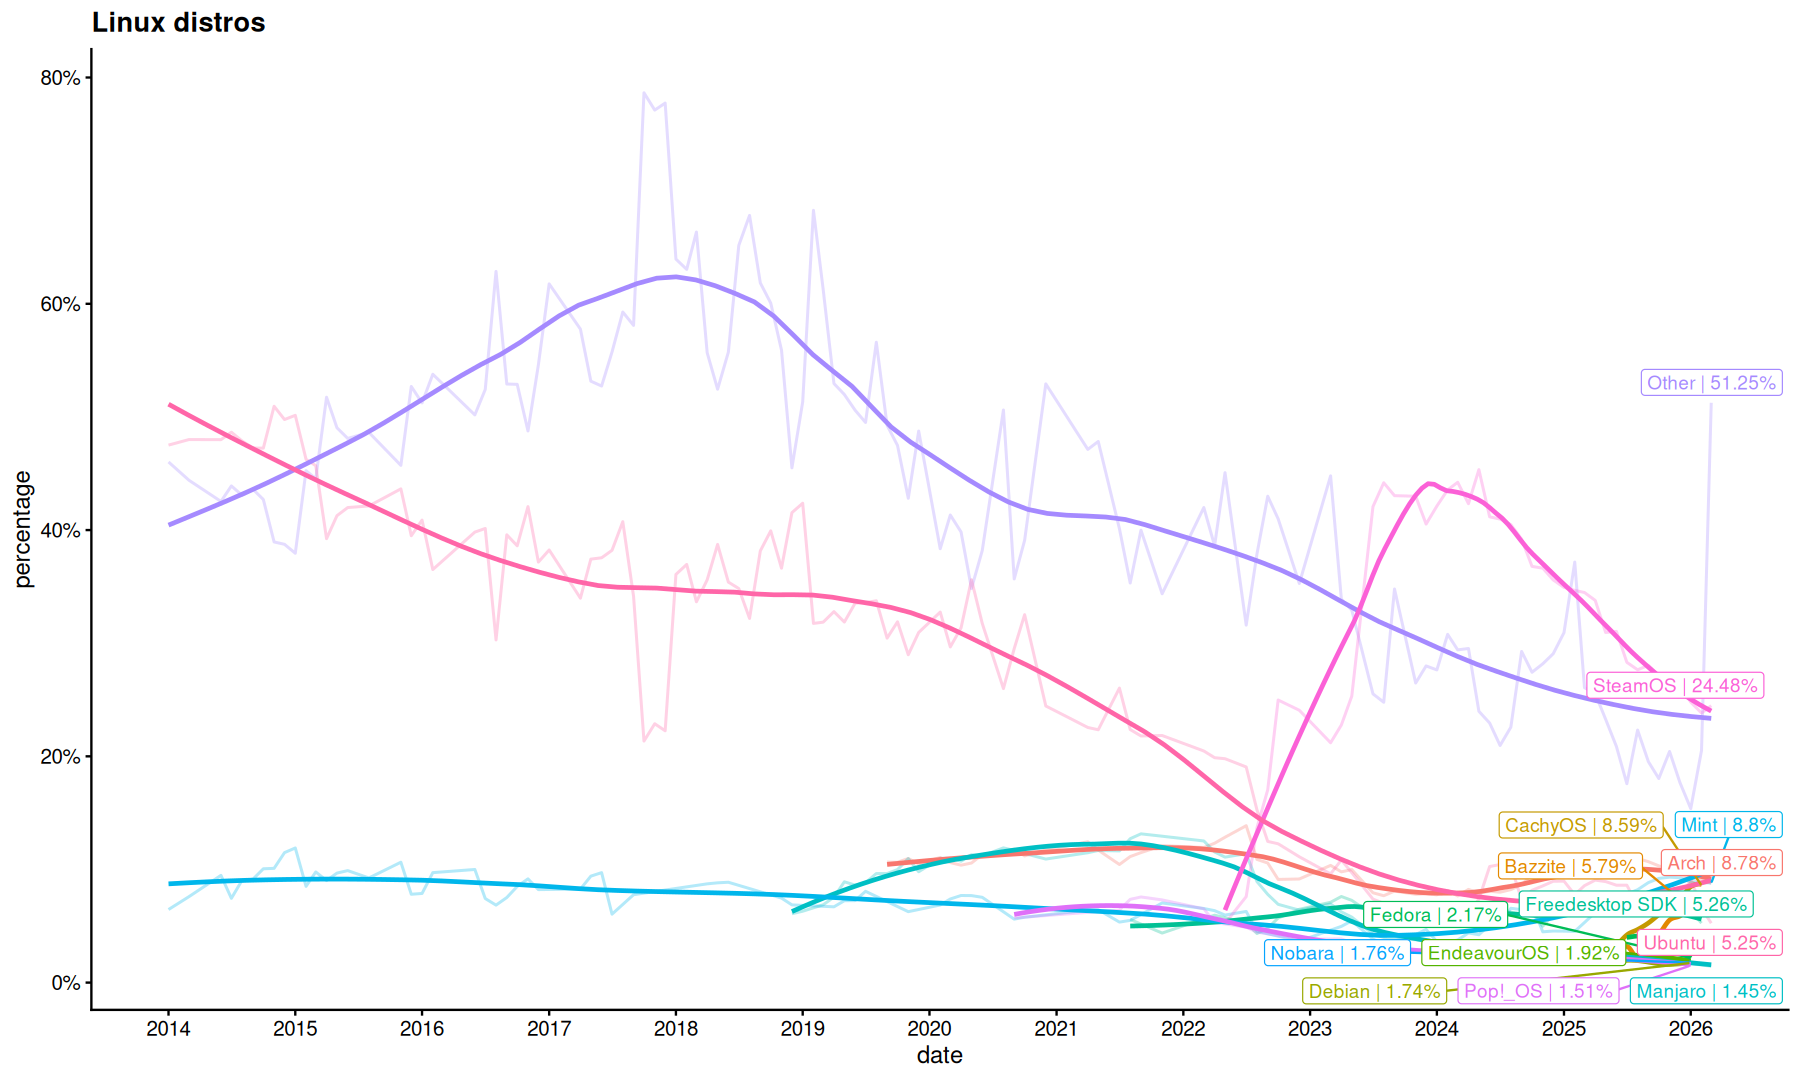

In [17]:
filter(df_plat, platform=='linux', category=='Linux Version') |>
mutate(
    distro=case_when(
        grepl('Ubuntu', name) ~ 'Ubuntu',
        grepl('Arch Linux', name) ~ 'Arch',
        grepl('SteamOS', name) ~ 'SteamOS',
        grepl('Pop!_OS', name) ~ 'Pop!_OS',
        grepl('Linux Mint', name) ~ 'Mint',
        grepl('Manjaro', name) ~ 'Manjaro',
        grepl('EndeavourOS', name) ~ 'EndeavourOS',
        grepl('CachyOS', name) ~ 'CachyOS',
        grepl('Bazzite', name) ~ 'Bazzite',
        grepl('Freedesktop', name) ~ 'Freedesktop SDK',
        grepl('Debian', name) ~ 'Debian',
        grepl('Nobara', name) ~ 'Nobara',
        grepl('Fedora', name) ~ 'Fedora',
        TRUE ~ 'Other'
    )
) -> df_distro
summarize(df_distro,
    percentage=sum(percentage),
    .by=c(date, distro)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf("%s | %.4g%%",distro,percentage*100), NA), .by=distro) |>
ggplot(aes(x=date, y=percentage, color=distro)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
guides(color='none') +
scale_y_continuous(labels=percent_format()) +
labs(title='Linux distros') +
scale_x_date(date_breaks='1 years', date_labels = '%Y') -> p
suppressWarnings(print(p))

Interesting to observe that Ubuntu went from the most popular distro in 2014 to 5% usage in 2026.

SteamOS is currently the most popular but it is on a declining trend.

There is a lot of "Other", that cannot be identified by the data:

In [18]:
filter(df_distro, distro=='Other', date==max(date)) |>
summarize(
    percentage=sum(percentage),
    .by=name
)

name,percentage
<chr>,<dbl>
0 64 bit,0.1760
64 bit,0.0801
Other,0.2564


"Freedesktop SDK" seems to be Steam packaged with Flatpak, but it is not present in latest 2026-03 month.

In [19]:
filter(df_distro, grepl('Freedesktop', distro)) |>
slice_max(date, n=1, by=name)

date,platform,category,name,change,percentage,distro
<date>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2021-08-01,linux,Linux Version,Description:Freedesktop.org 20.08.14 (Flatpak runtime) 64 bit,0.0558,0.0558,Freedesktop SDK
2021-11-01,linux,Linux Version,Description:Freedesktop.org 21.08.4 (Flatpak runtime) 64 bit,-0.0090,0.0438,Freedesktop SDK
2022-04-01,linux,Linux Version,Description:Freedesktop.org 21.08.12 (Flatpak runtime) 64 bit,0.0596,0.0596,Freedesktop SDK
2022-07-01,linux,Linux Version,Description:Freedesktop.org 21.08.14 (Flatpak runtime) 64 bit,-0.0076,0.0529,Freedesktop SDK
2022-08-01,linux,Linux Version,Freedesktop.org 21.08.15 (Flatpak runtime) 64 bit,0.0434,0.0434,Freedesktop SDK
2023-08-01,linux,Linux Version,Freedesktop.org SDK 22.08 (Flatpak runtime) 64 bit,0.0004,0.0603,Freedesktop SDK
2023-11-01,linux,Linux Version,Freedesktop.org SDK 23.08 (Flatpak runtime) 64 bit,-0.0040,0.0533,Freedesktop SDK
2024-10-01,linux,Linux Version,Freedesktop SDK 23.08 (Flatpak runtime) 64 bit,0.0013,0.0616,Freedesktop SDK
2025-10-01,linux,Linux Version,Freedesktop SDK 24.08 (Flatpak runtime) 64 bit,-0.0398,0.0231,Freedesktop SDK


### MacOS version

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


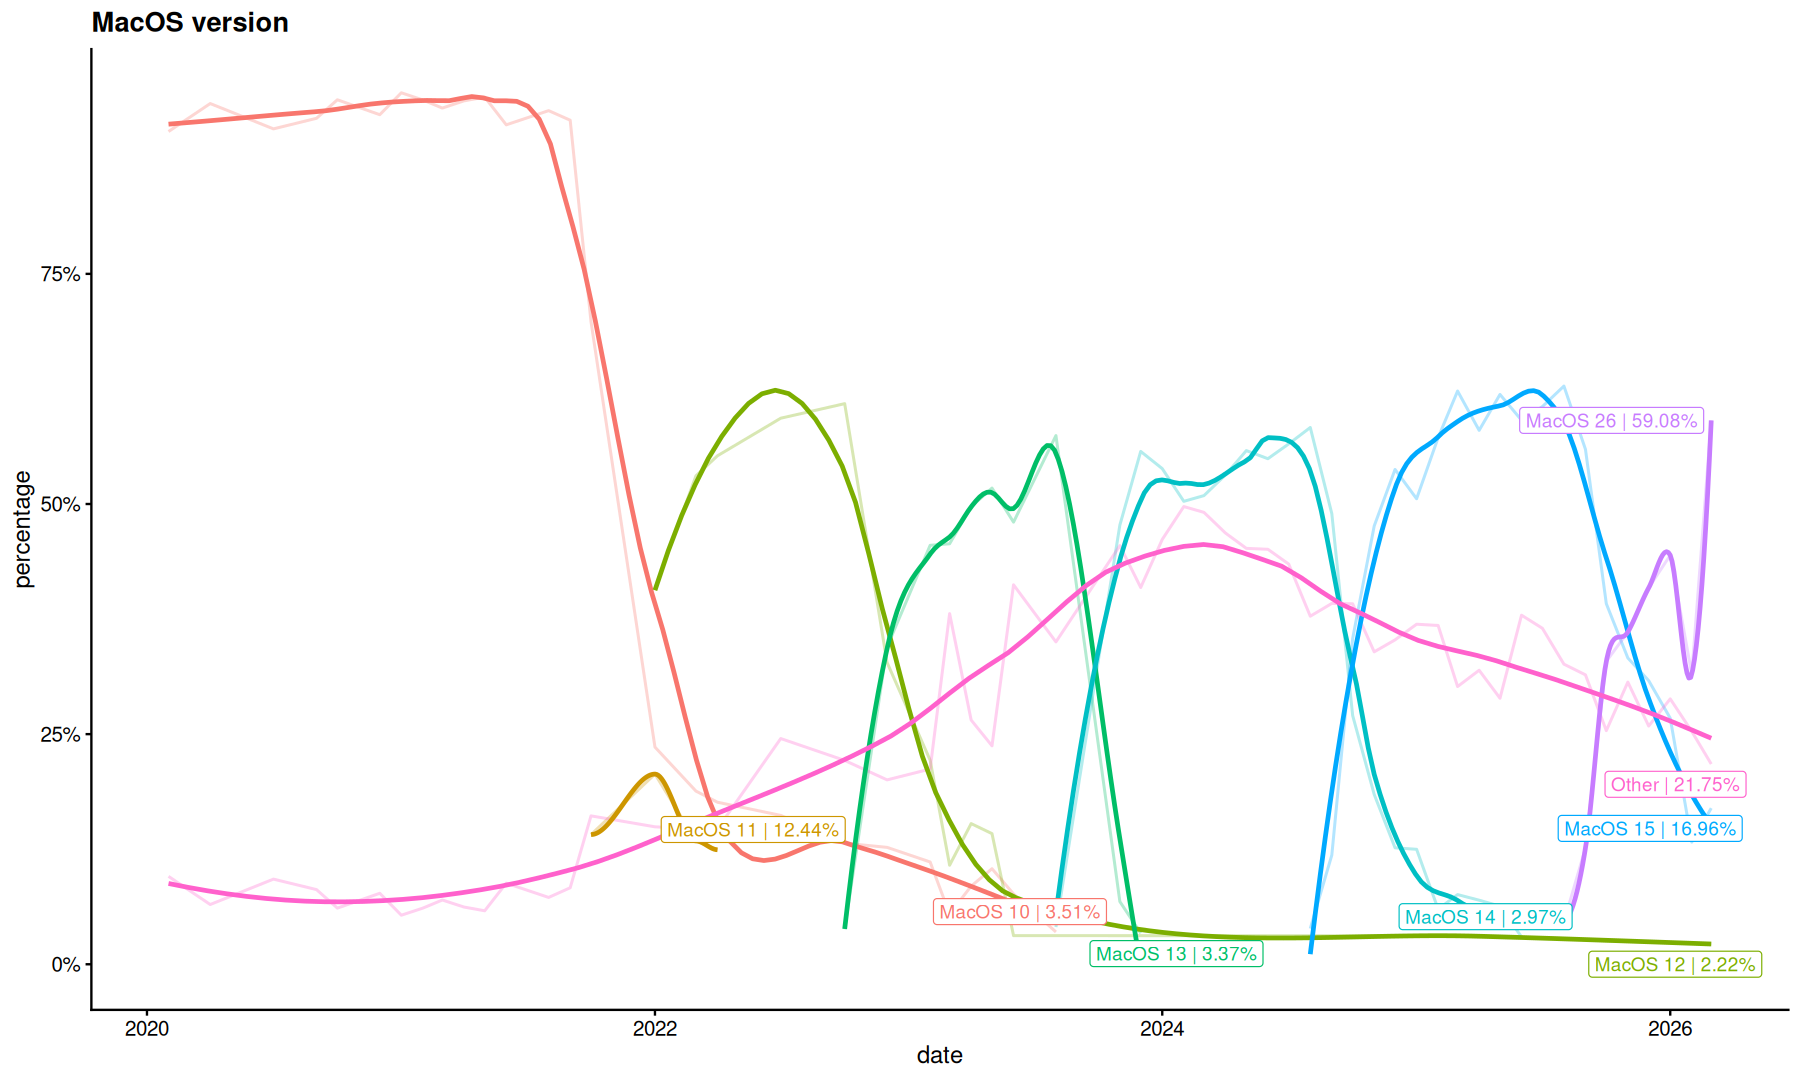

In [20]:
filter(df_plat, platform=='mac', category=='OSX Version') |>
mutate(
    ver=str_extract(name, '(MacOS \\d+)', group=1),
    ver=replace_na(ver, 'Other')
) |>
summarize(
    percentage=sum(percentage),
    .by=c(date, ver)
) |>
filter(date > ymd('2020-01-01')) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf("%s | %.4g%%",ver,percentage*100), NA), .by=ver) |>
ggplot(aes(x=date, y=percentage, color=ver)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
labs(title='MacOS version') +
scale_y_continuous(labels=percent_format()) +
guides(color='none') -> p
suppressWarnings(print(p))

### Windows version

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


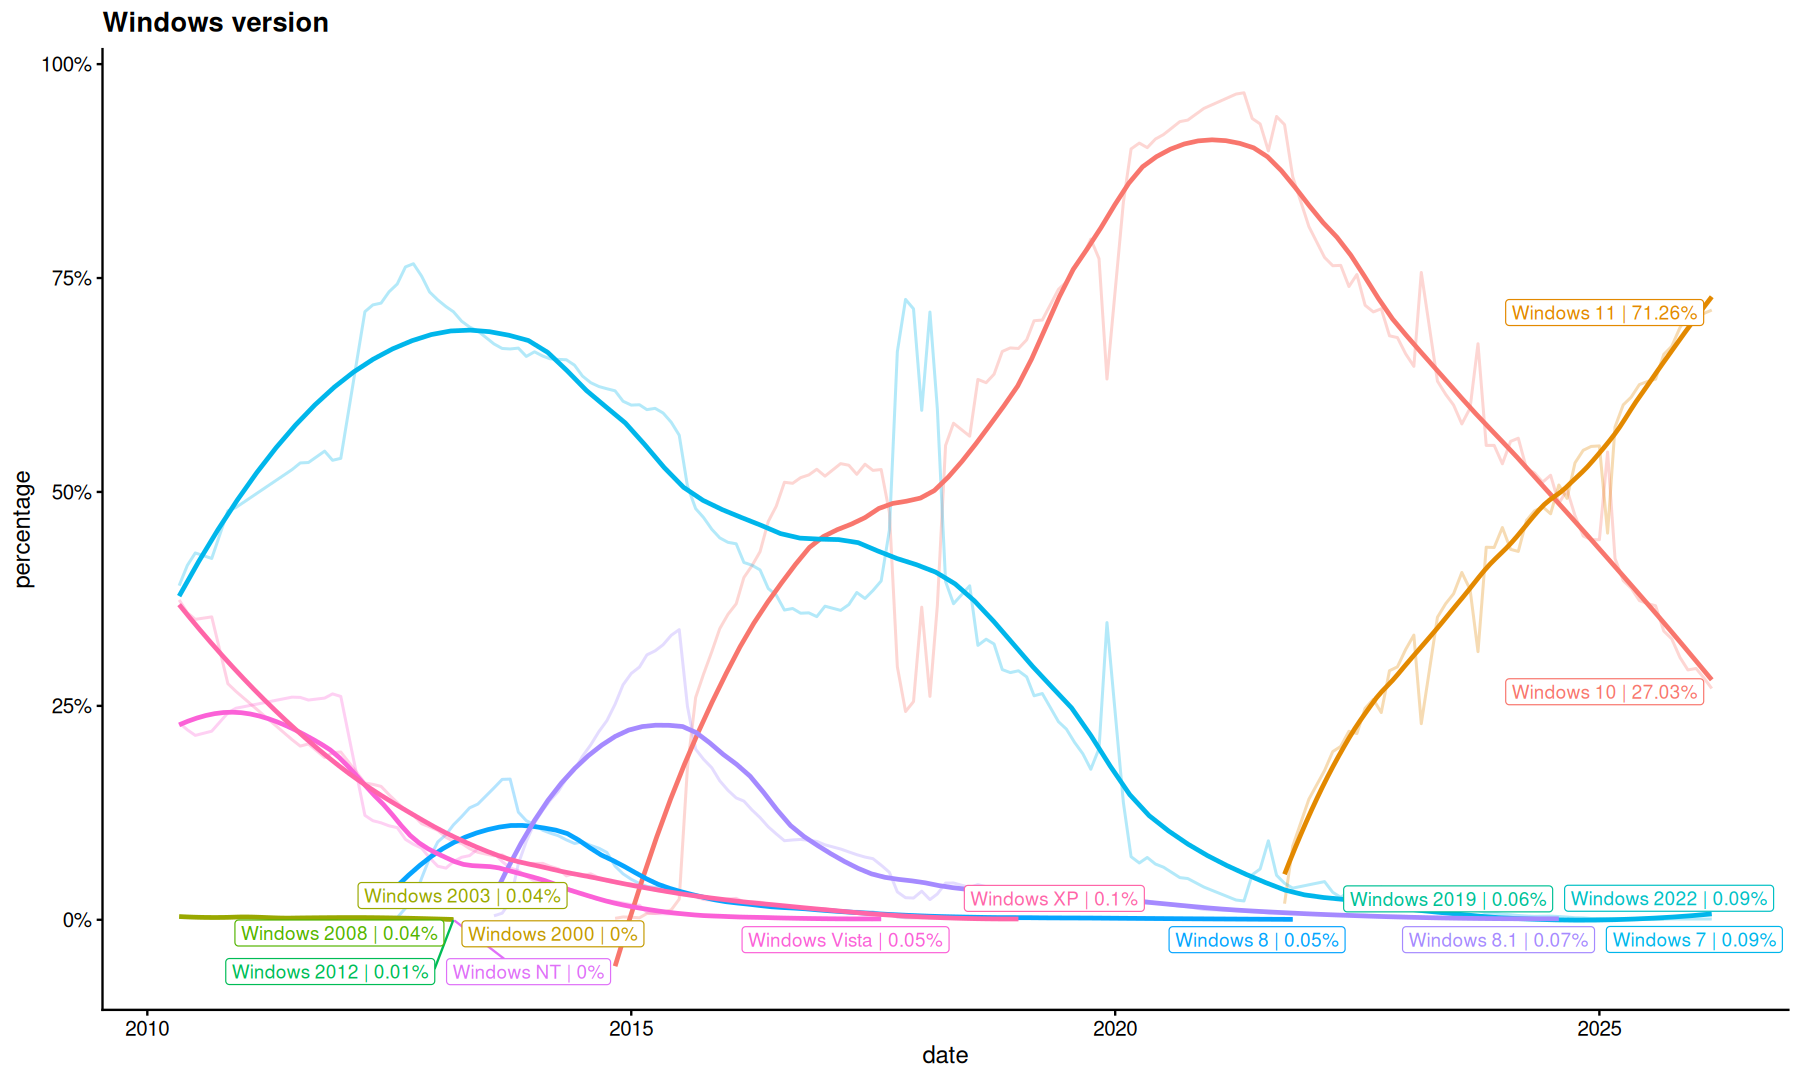

In [21]:
filter(df_plat, platform=='pc', grepl('Windows Version',category)) |>
filter(grepl('Windows', name)) |>
mutate(
    ver=gsub(' (64|32) bit','', name)
) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, ver)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf("%s | %.4g%%",ver,percentage*100), NA), .by=ver) |>
ggplot(aes(x=date, y=percentage, color=ver)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
labs(title='Windows version') +
guides(color='none') +
scale_y_continuous(labels=percent_format()) -> p
suppressWarnings(print(p))

## Display Resolution

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 2864 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


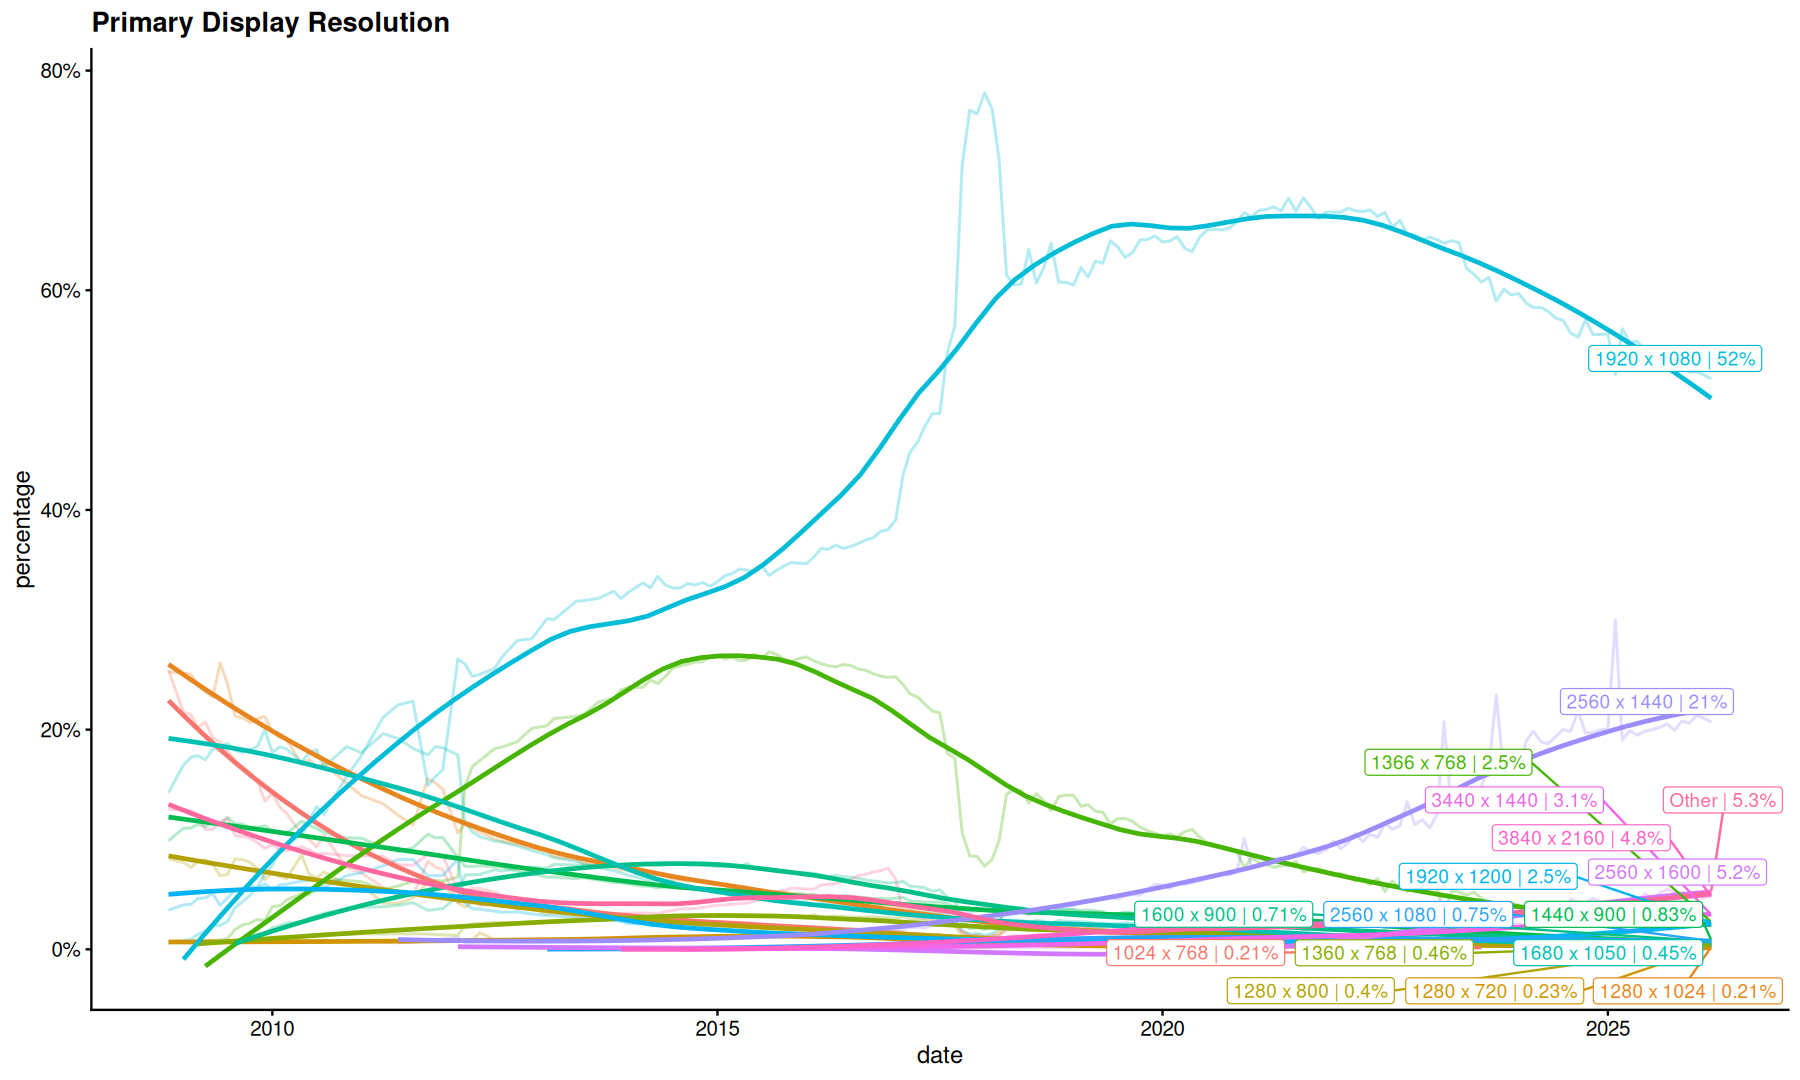

In [22]:
filter(df, category=='Primary Display Resolution') |>
mutate(
    disp = fct_lump_prop(name, w = percentage, prop = 0.005)
) |>
summarize(
    percentage=sum(percentage),
    .by=c(date, disp)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',disp,100*percentage), NA), .by=disp) |>
ggplot(aes(x=date, y=percentage, color=disp)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
scale_y_continuous(labels=scales::percent_format()) +
labs(title='Primary Display Resolution') +
guides(color='none')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 936 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


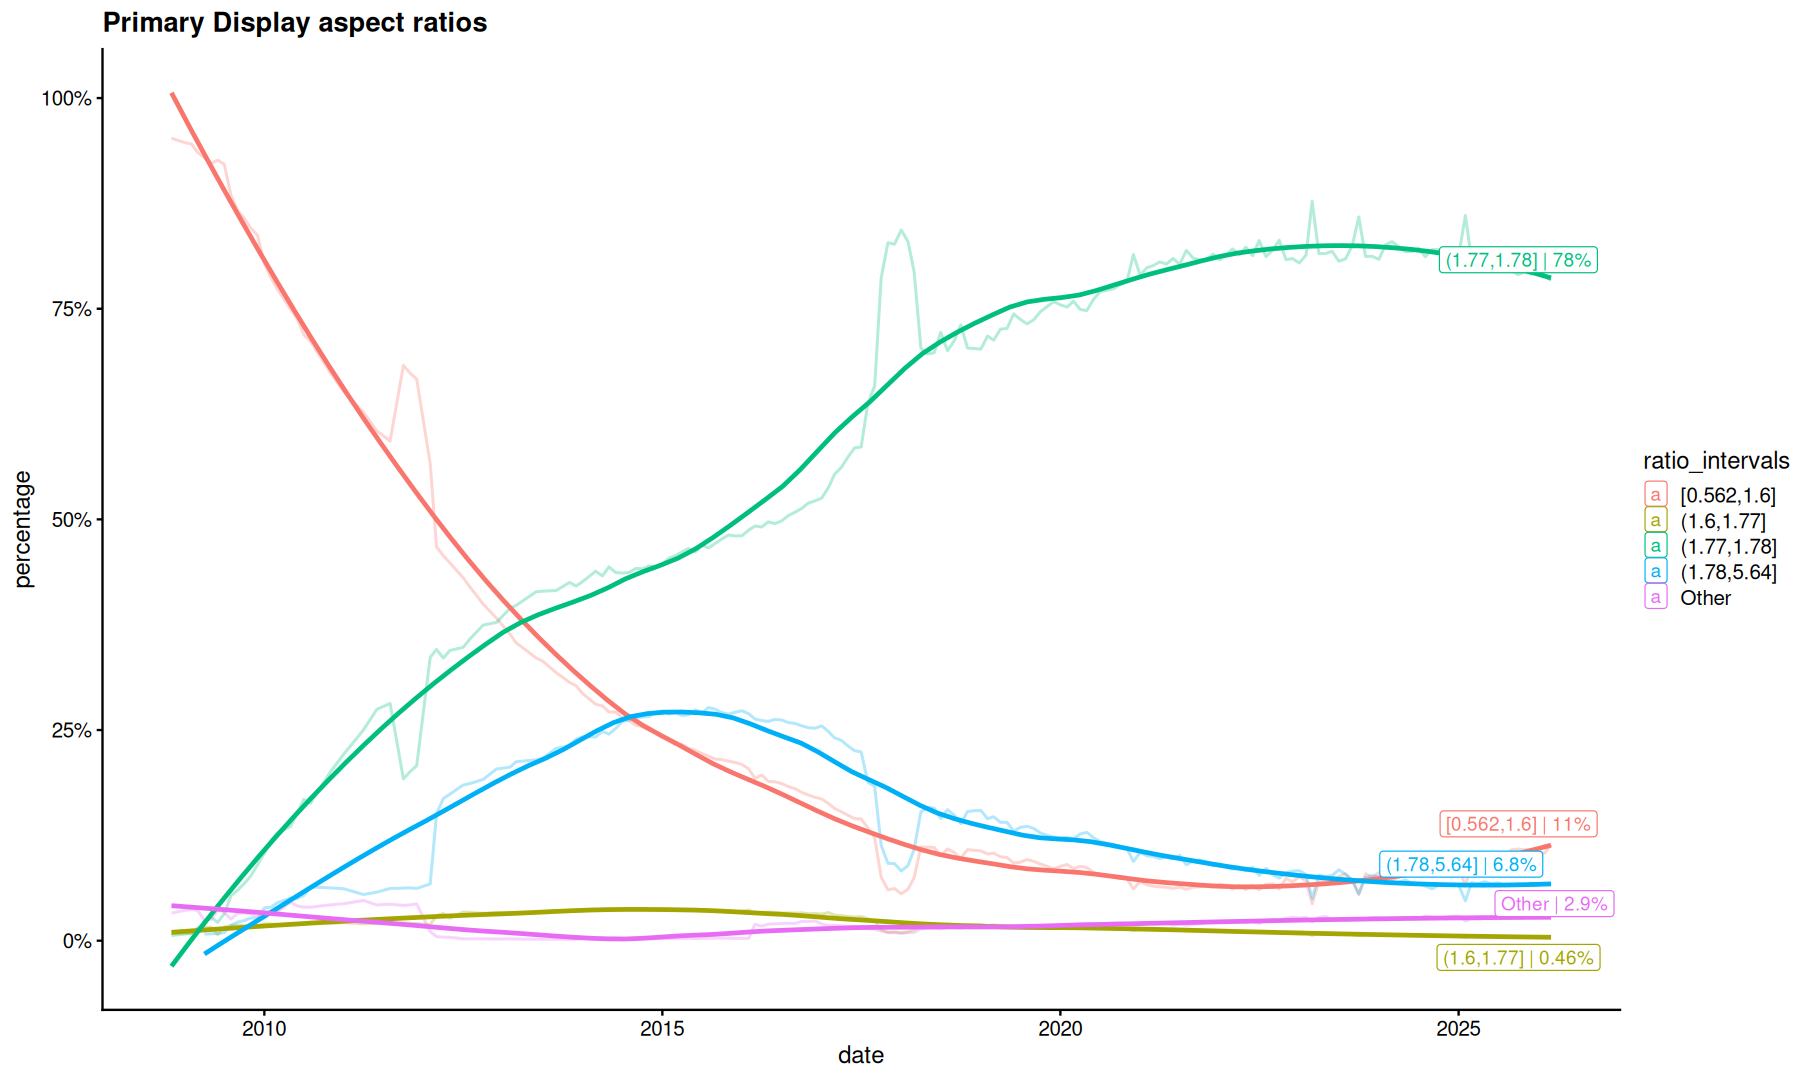

In [23]:
filter(df, category=='Primary Display Resolution') |>
mutate(
    w = as.numeric(str_extract(name, '^(\\d+)', group=1)),
    h = as.numeric(str_extract(name, 'x (\\d+)', group=1)),
    ratio = w/h,
    ratio_intervals = cut(ratio, breaks=quantile(ratio, na.rm=TRUE), include.lowest = TRUE),
    ratio_intervals = fct_na_value_to_level(ratio_intervals, level = 'Other')
) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, ratio_intervals)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',ratio_intervals,100*percentage), NA), .by=ratio_intervals) |>
ggplot(aes(x=date, y=percentage, color=ratio_intervals)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label)) +
scale_y_continuous(labels=scales::percent_format()) +
labs(title='Primary Display aspect ratios')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 2906 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


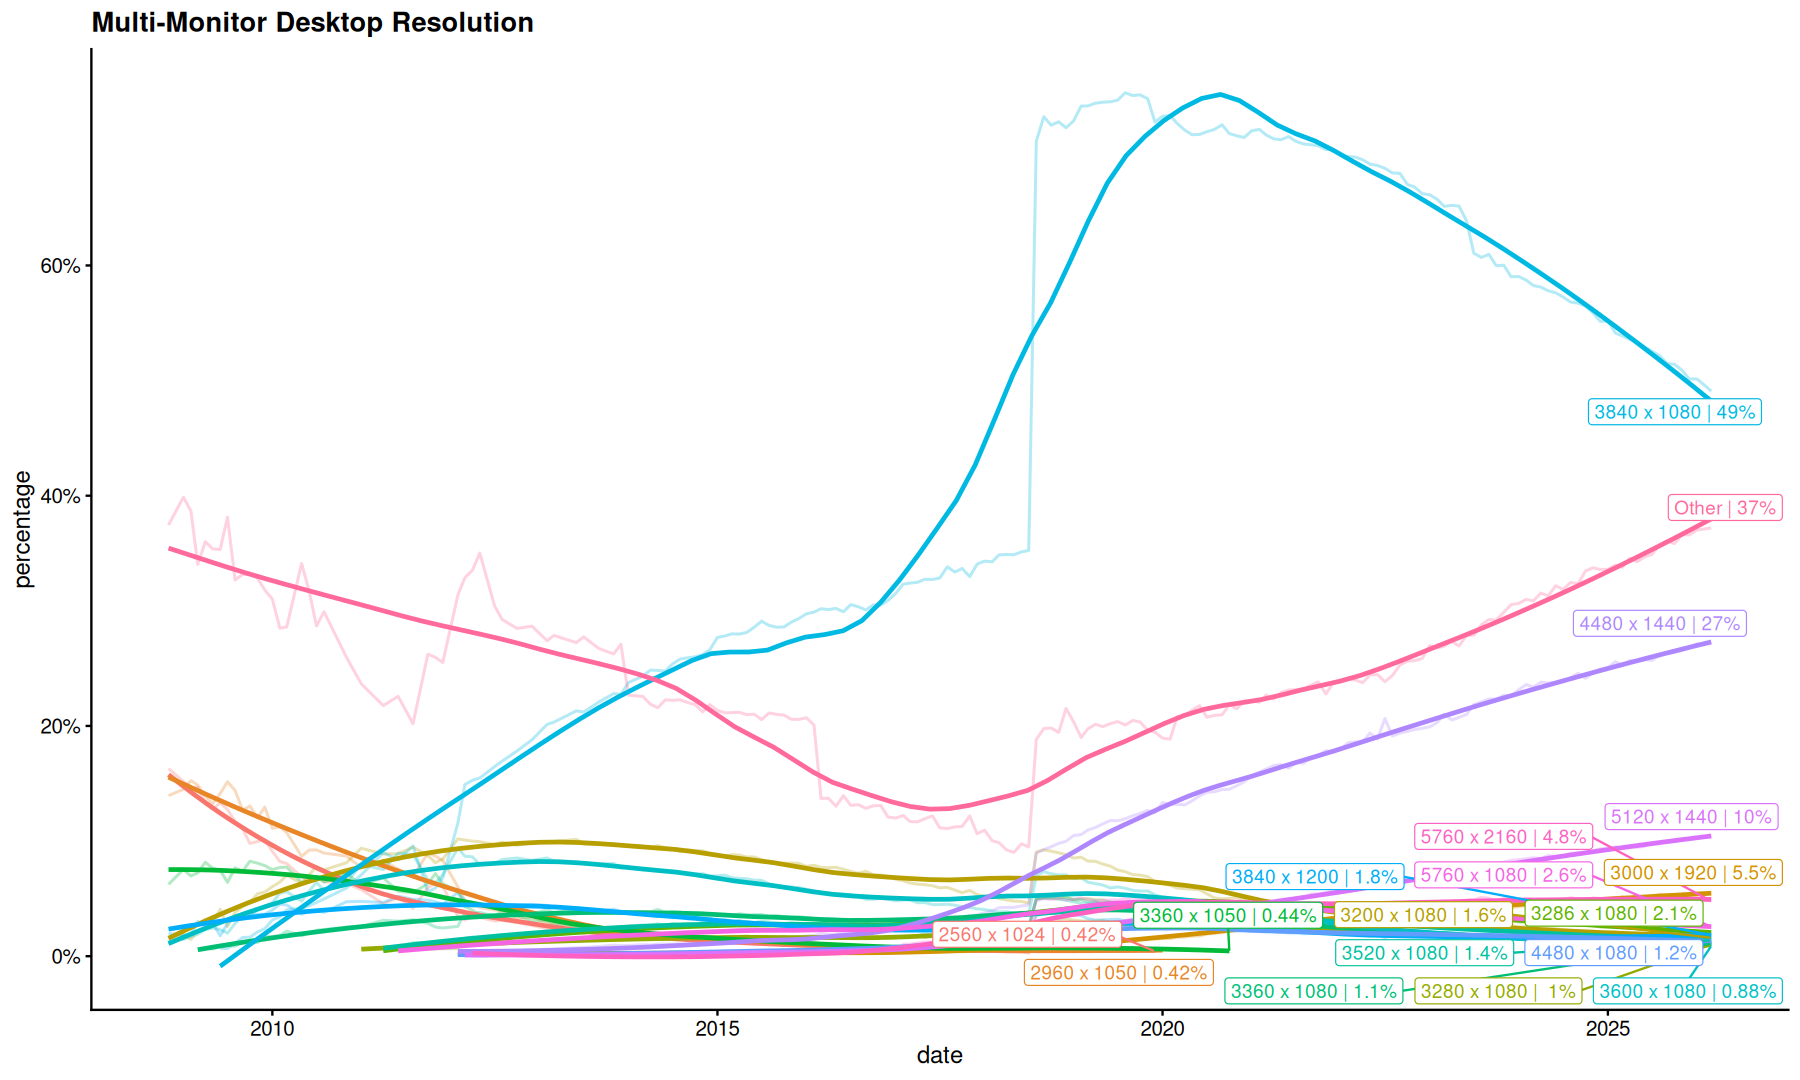

In [24]:
filter(df, category=='Multi-Monitor Desktop Resolution') |>
filter(name != 'Other') |>
mutate(
    disp = fct_lump_prop(name, w = percentage, prop = 0.01)
) |>
summarize(
    percentage=sum(percentage),
    .by=c(date, disp)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',disp,100*percentage), NA), .by=disp) |>
ggplot(aes(x=date, y=percentage, color=disp)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
scale_y_continuous(labels=scales::percent_format()) +
labs(title='Multi-Monitor Desktop Resolution') +
guides(color='none')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 746 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


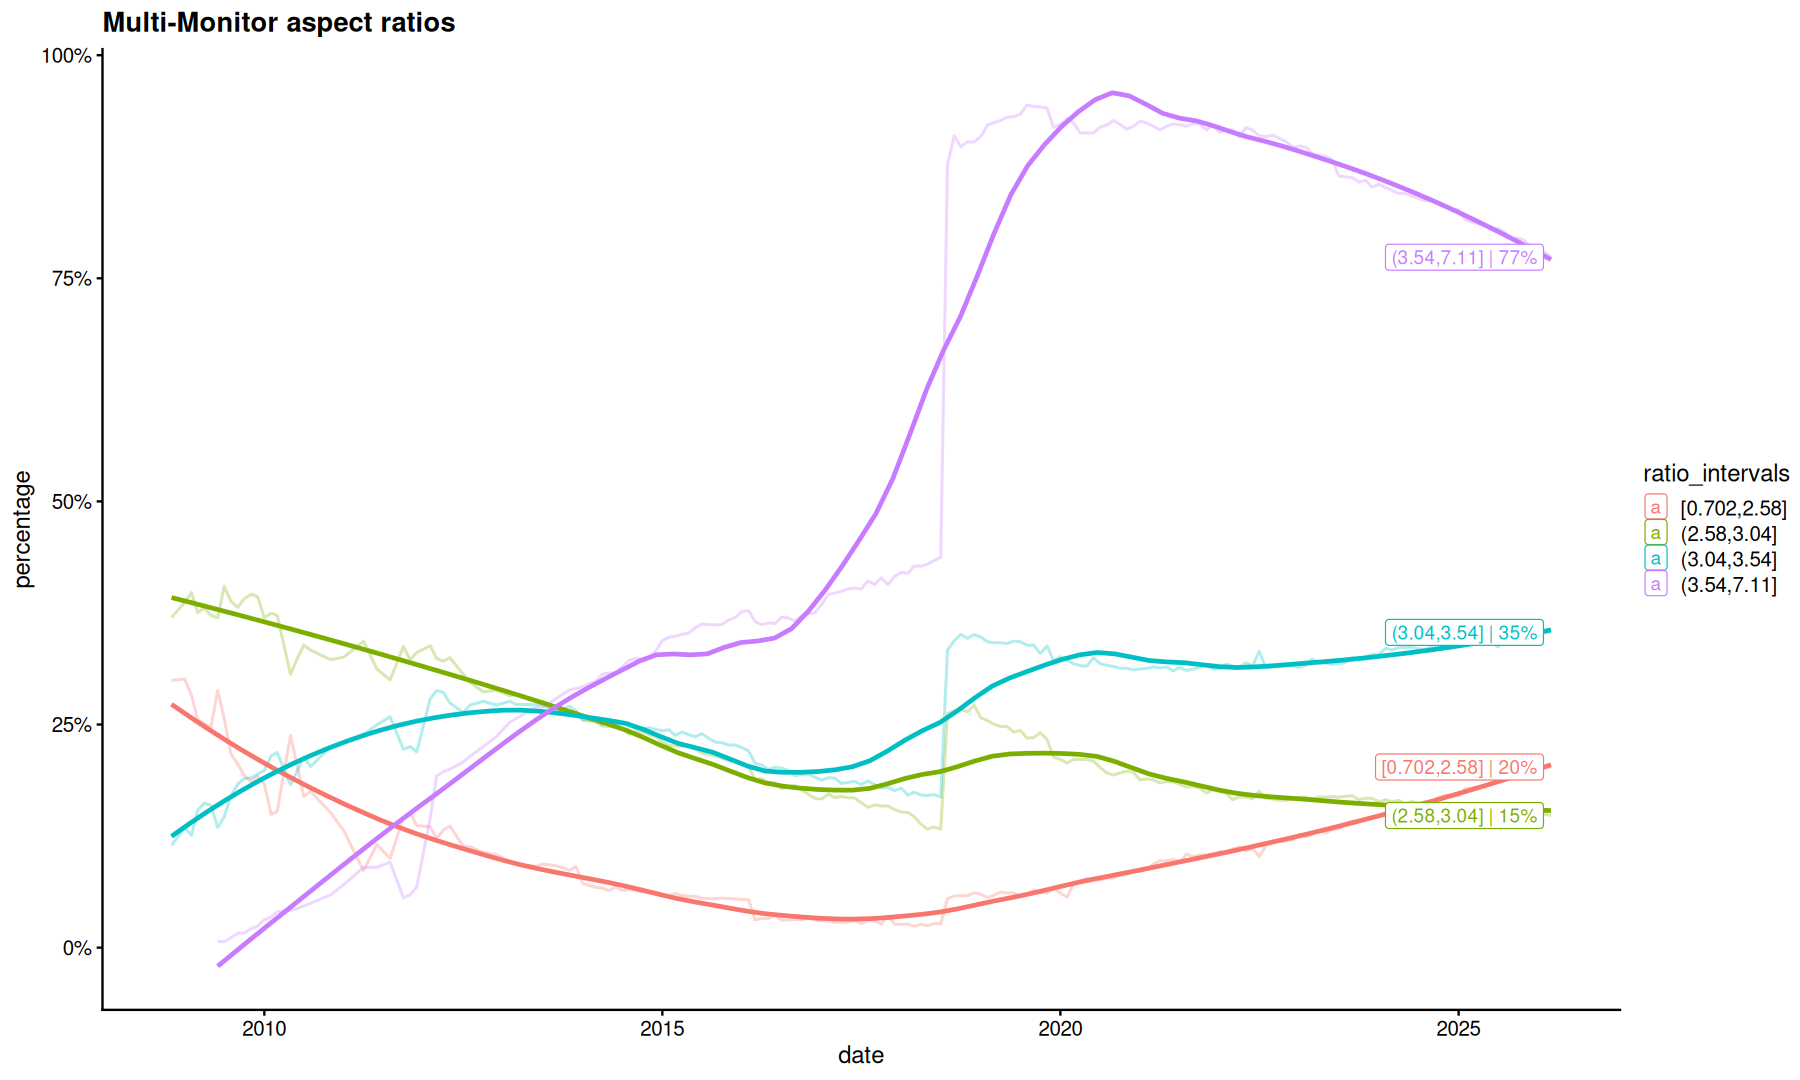

In [25]:
filter(df, category=='Multi-Monitor Desktop Resolution') |>
filter(name != 'Other') |>
mutate(
    w = as.numeric(str_extract(name, '^(\\d+)', group=1)),
    h = as.numeric(str_extract(name, 'x (\\d+)', group=1)),
    ratio = w/h,
    ratio_intervals = cut(ratio, breaks=quantile(ratio, na.rm=TRUE), include.lowest = TRUE),
    ratio_intervals = fct_na_value_to_level(ratio_intervals, level = 'Other')
) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, ratio_intervals)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',ratio_intervals,100*percentage), NA), .by=ratio_intervals) |>
ggplot(aes(x=date, y=percentage, color=ratio_intervals)) +
geom_line(alpha=0.3) +
geom_smooth(se=F,span=0.5, linewidth=1) +
scale_y_continuous(labels=scales::percent_format()) +
geom_label_repel(aes(label=label)) +
labs(title='Multi-Monitor aspect ratios')

## Languages

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


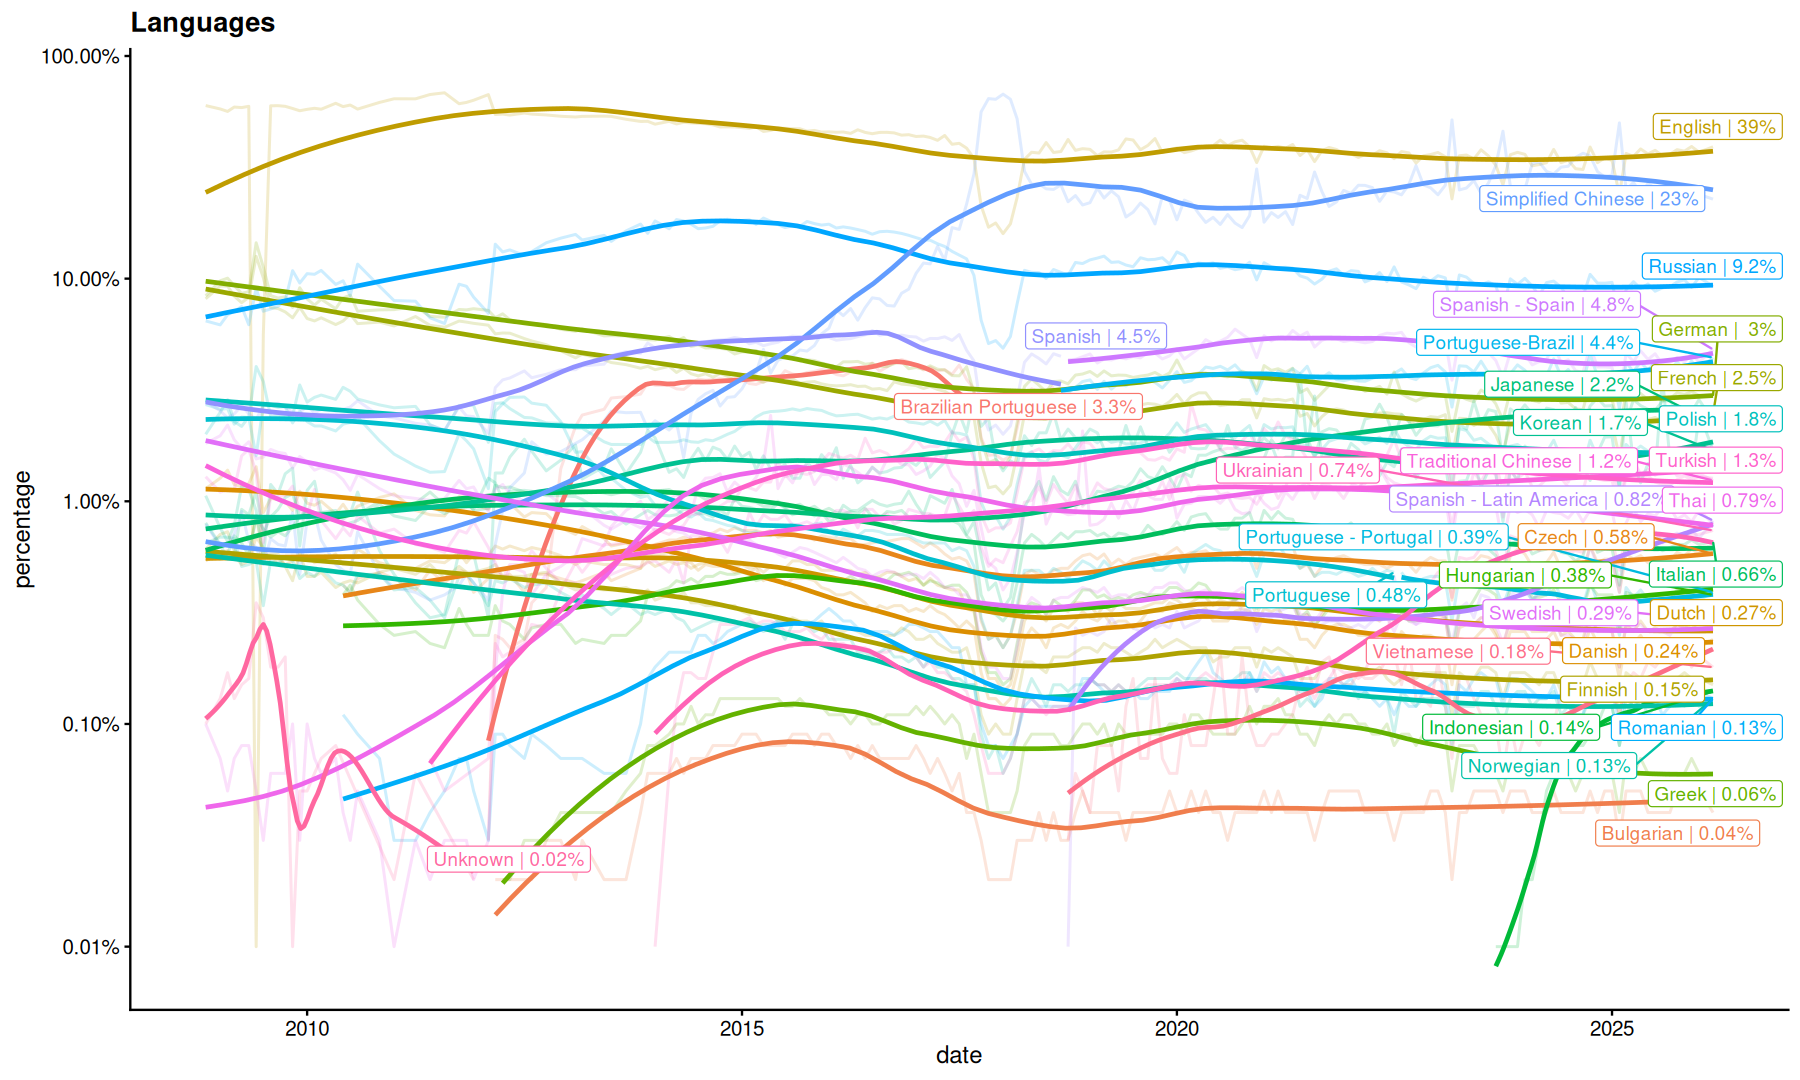

In [26]:
filter(df, category=='Language') |>
filter(!is.na(percentage), percentage>0) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %2.2g%%',name,100*percentage), NA), .by=name) |>
ggplot(aes(x=date, y=percentage, color=name)) +
geom_line(alpha=0.2) +
geom_smooth(se=F,span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
scale_y_continuous(trans='log10', labels=scales::percent_format()) +
labs(title='Languages') +
guides(color='none') -> p
suppressWarnings(print(p))

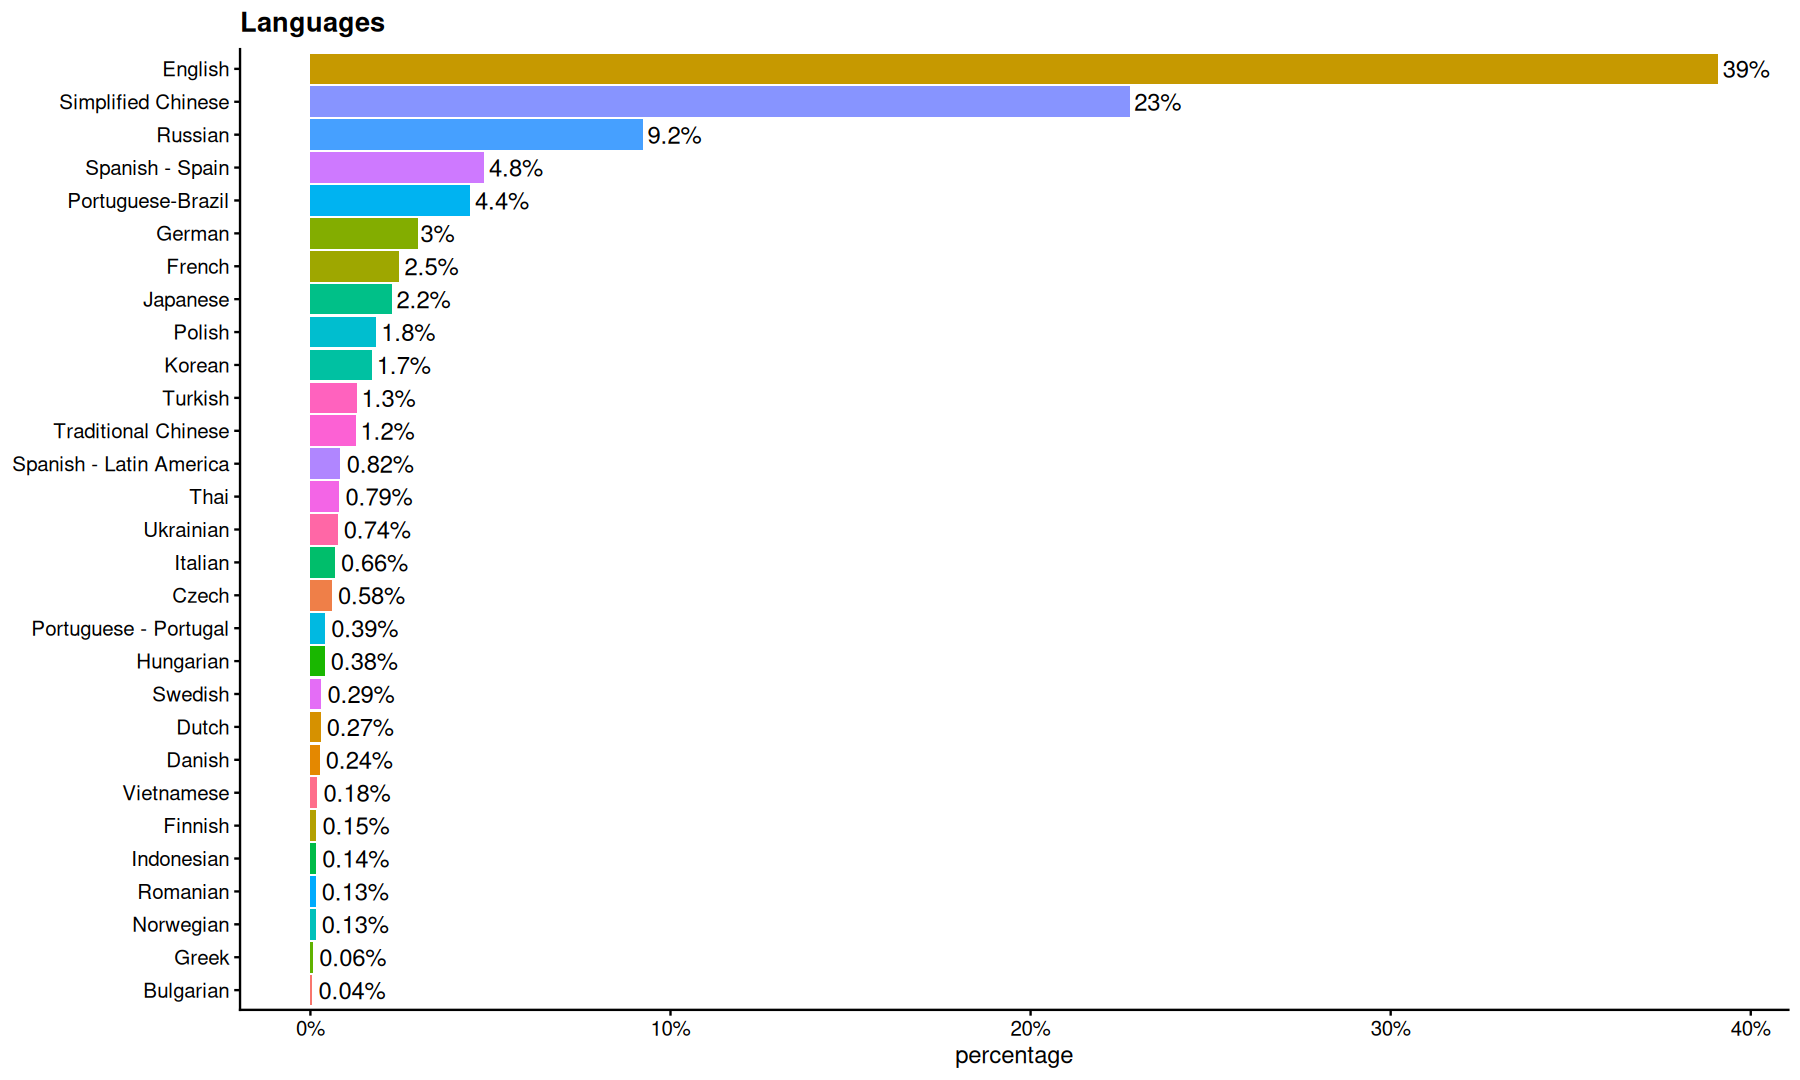

In [27]:
filter(df, category=='Language') |>
filter(date==max(date)) |>
filter(percentage>0) |>
ggplot(aes(y=fct_reorder(name, percentage), x=percentage, fill=name)) +
geom_col() +
geom_text(aes(label=sprintf("%.2g%%",percentage*100)), hjust=-.1) +
scale_x_continuous(labels=percent_format()) +
labs(title='Languages', y=NULL) +
guides(fill='none')

## Drive Space

### Total Space

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 752 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


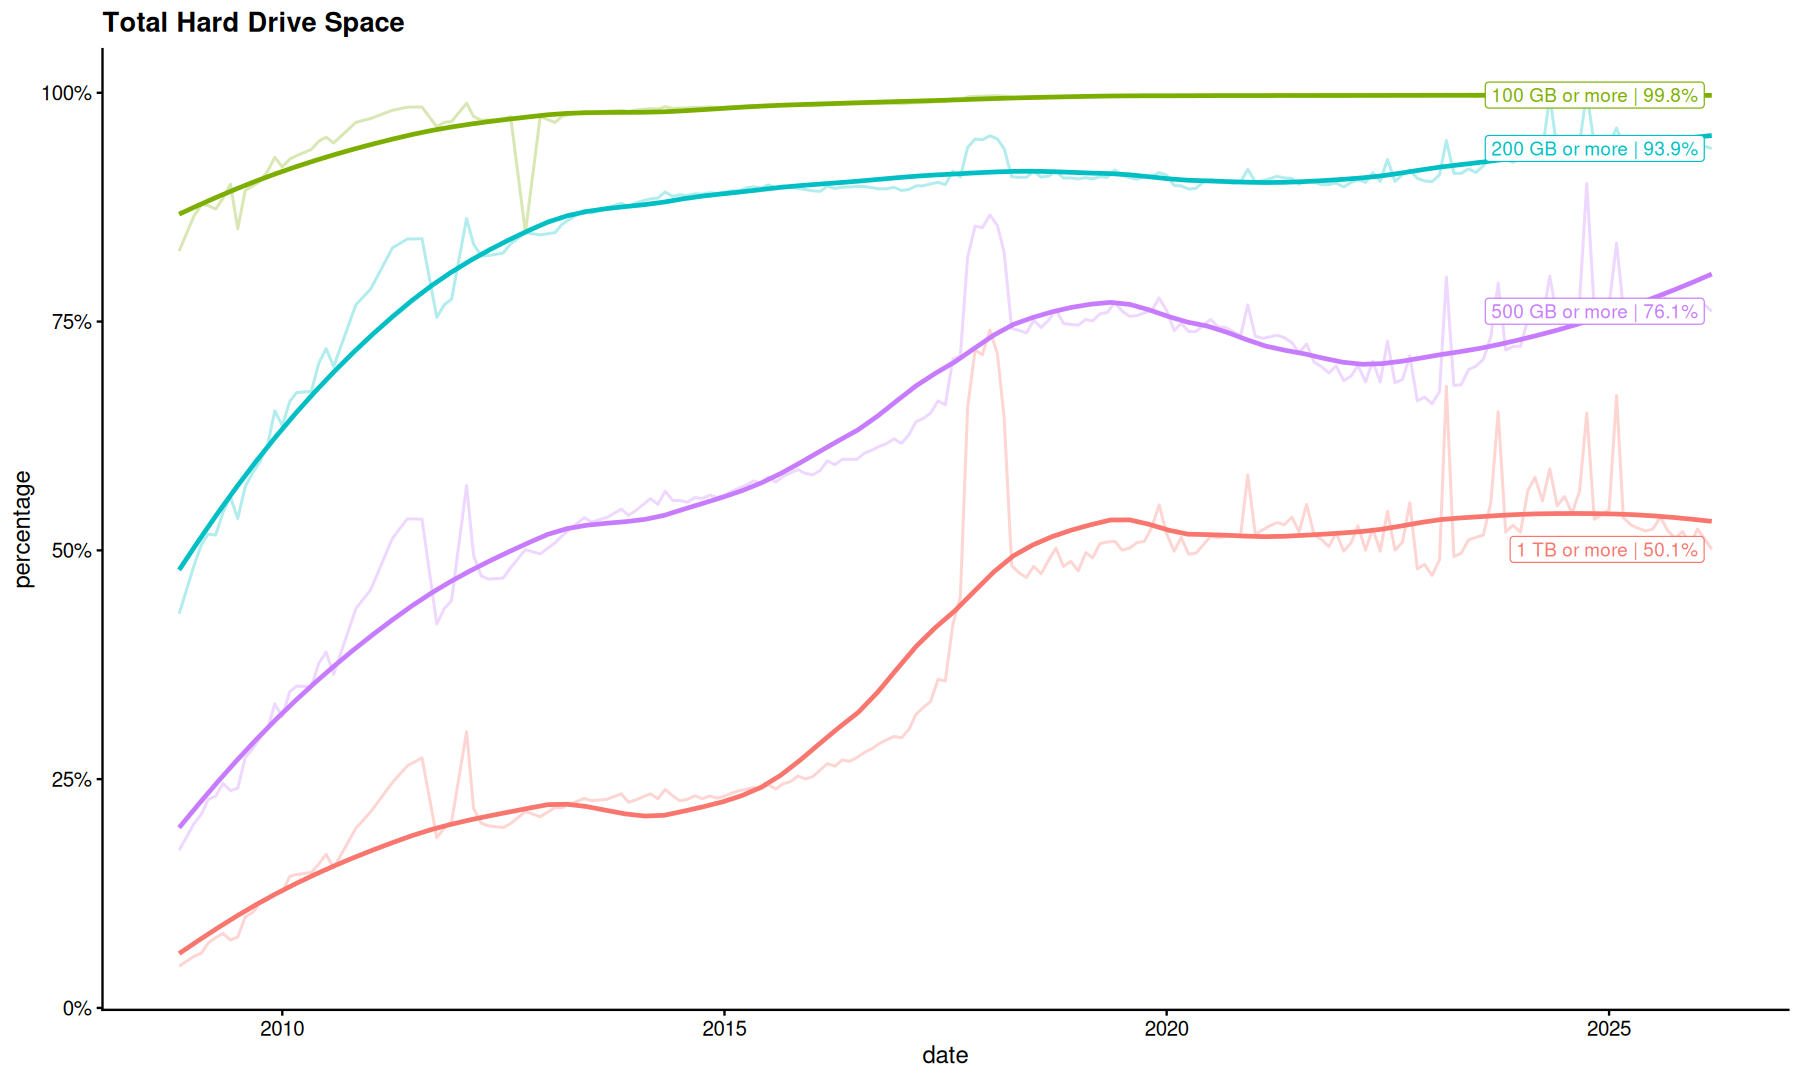

In [28]:
map_df(c(100, 200, 500, 1000), function(target_gb) {
    filter(df, category=='Total Hard Drive Space') |>
    mutate(
        lb_gb = case_when(
            grepl('\\d+ GB to', name) ~ as.numeric(str_extract(name, '(\\S+) GB to', group=1)),
            grepl('Above \\d+ TB', name) ~ as.numeric(str_extract(name, '(\\S+) TB', group=1))*1000,
        )
    ) |>
    filter(lb_gb >= target_gb) |>
    distinct(date, percentage) |>
    mutate(
        gb=case_when(
               target_gb >= 1000 ~ sprintf("%.3g TB or more", target_gb/1000),
               TRUE ~ sprintf("%d GB or more", target_gb)
            )
    )
}) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, gb)
) |>
mutate(percentage=pmin(percentage, 1)) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %.3g%%', gb, percentage*100), NA), .by=gb) |>
ggplot(aes(x=date, y=percentage, color=gb)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label)) +
labs(title='Total Hard Drive Space') +
guides(color='none') +
scale_y_continuous(label=percent_format())

### Free Space

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 1022 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


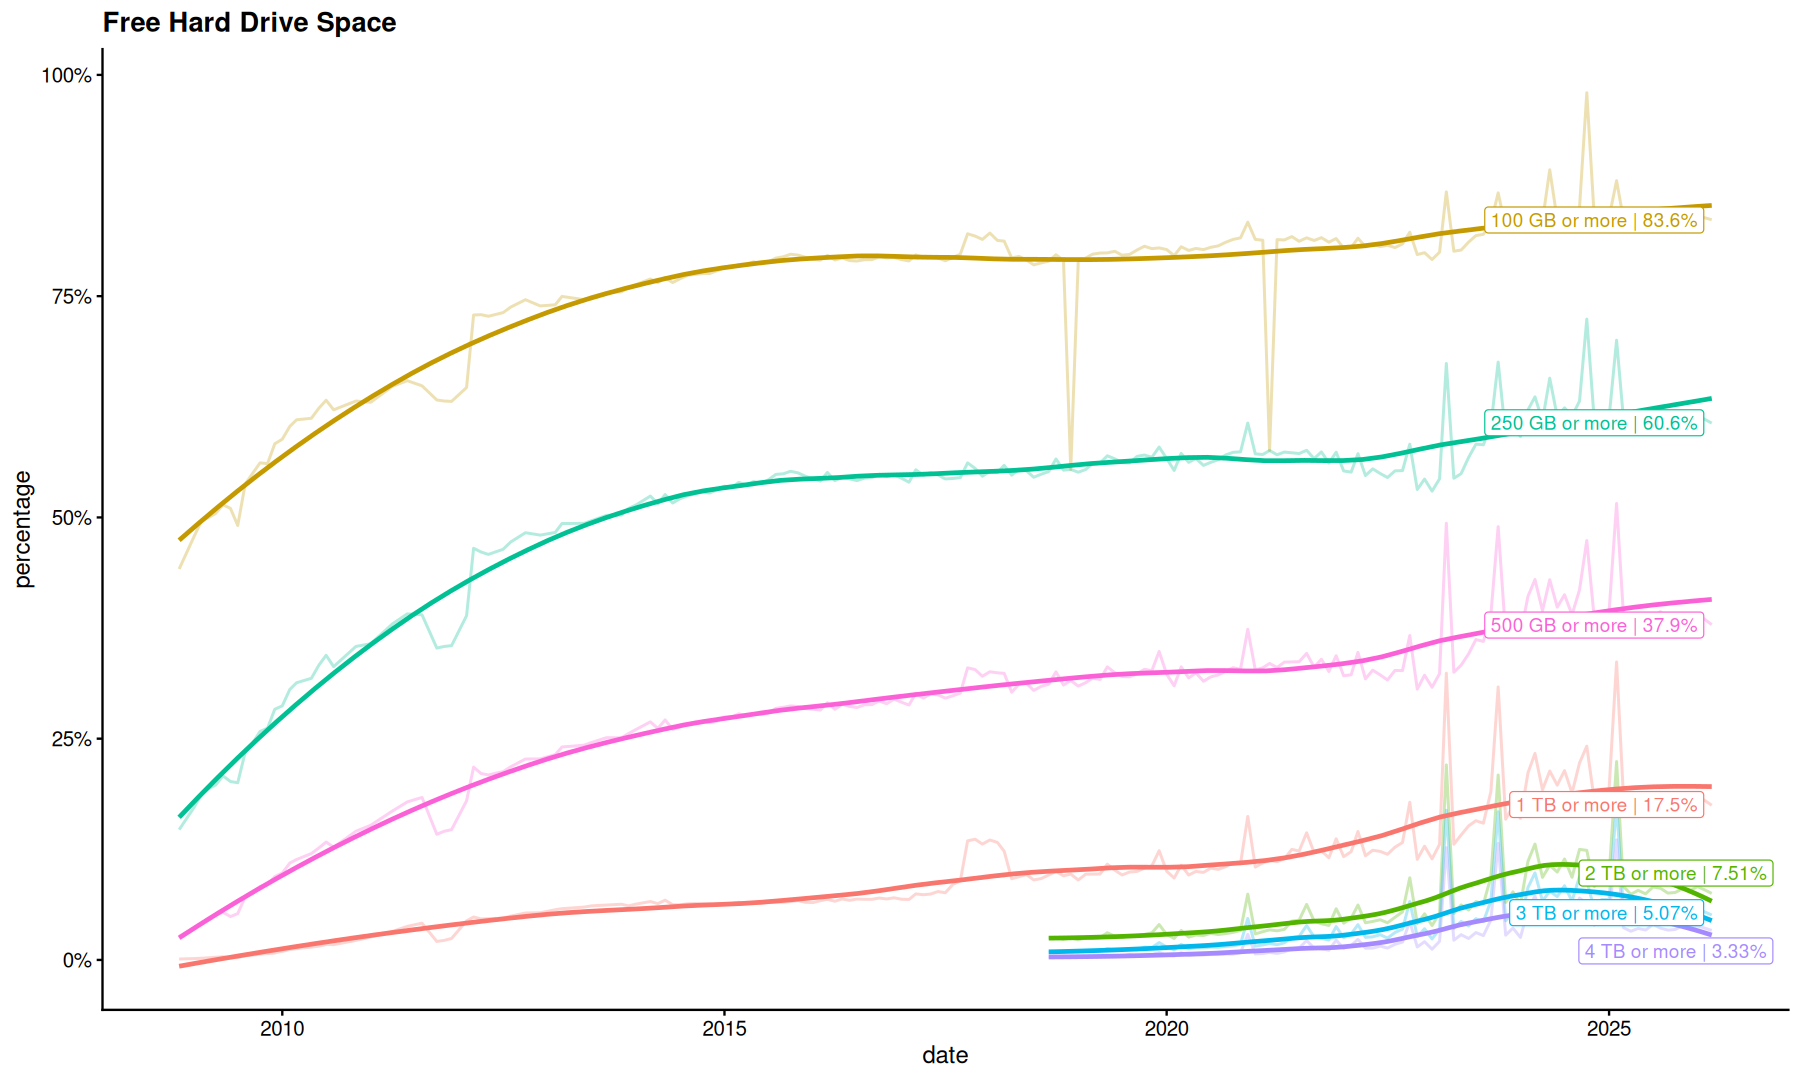

In [29]:
map_df(c(100, 250, 500, 1000, 2000, 3000, 4000), function(target_gb) {
    filter(df, category=='Free Hard Drive Space') |>
    mutate(
        lb_gb = case_when(
            grepl('\\d+ GB to', name) ~ as.numeric(str_extract(name, '(\\S+) GB to', group=1)),
            grepl('\\d+ TB to', name) ~ as.numeric(str_extract(name, '(\\S+) TB to', group=1))*1000,
            grepl('Above \\d+ TB', name) ~ as.numeric(str_extract(name, '(\\S+) TB', group=1))*1000,
        )
    ) |>
    filter(lb_gb >= target_gb) |>
    distinct(date, percentage) |>
    mutate(
        gb=case_when(
               target_gb >= 1000 ~ sprintf("%.3g TB or more", target_gb/1000),
               TRUE ~ sprintf("%d GB or more", target_gb)
            )
    )
}) |>
summarize(
    percentage=sum(percentage),
    .by = c(date, gb)
) |>
mutate(percentage=pmin(percentage, 1)) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %.3g%%', gb, percentage*100), NA), .by=gb) |>
ggplot(aes(x=date, y=percentage, color=gb)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label)) +
labs(title='Free Hard Drive Space') +
guides(color='none') +
scale_y_continuous(label=percent_format())

## VR Headsets

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
"Removed 729 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


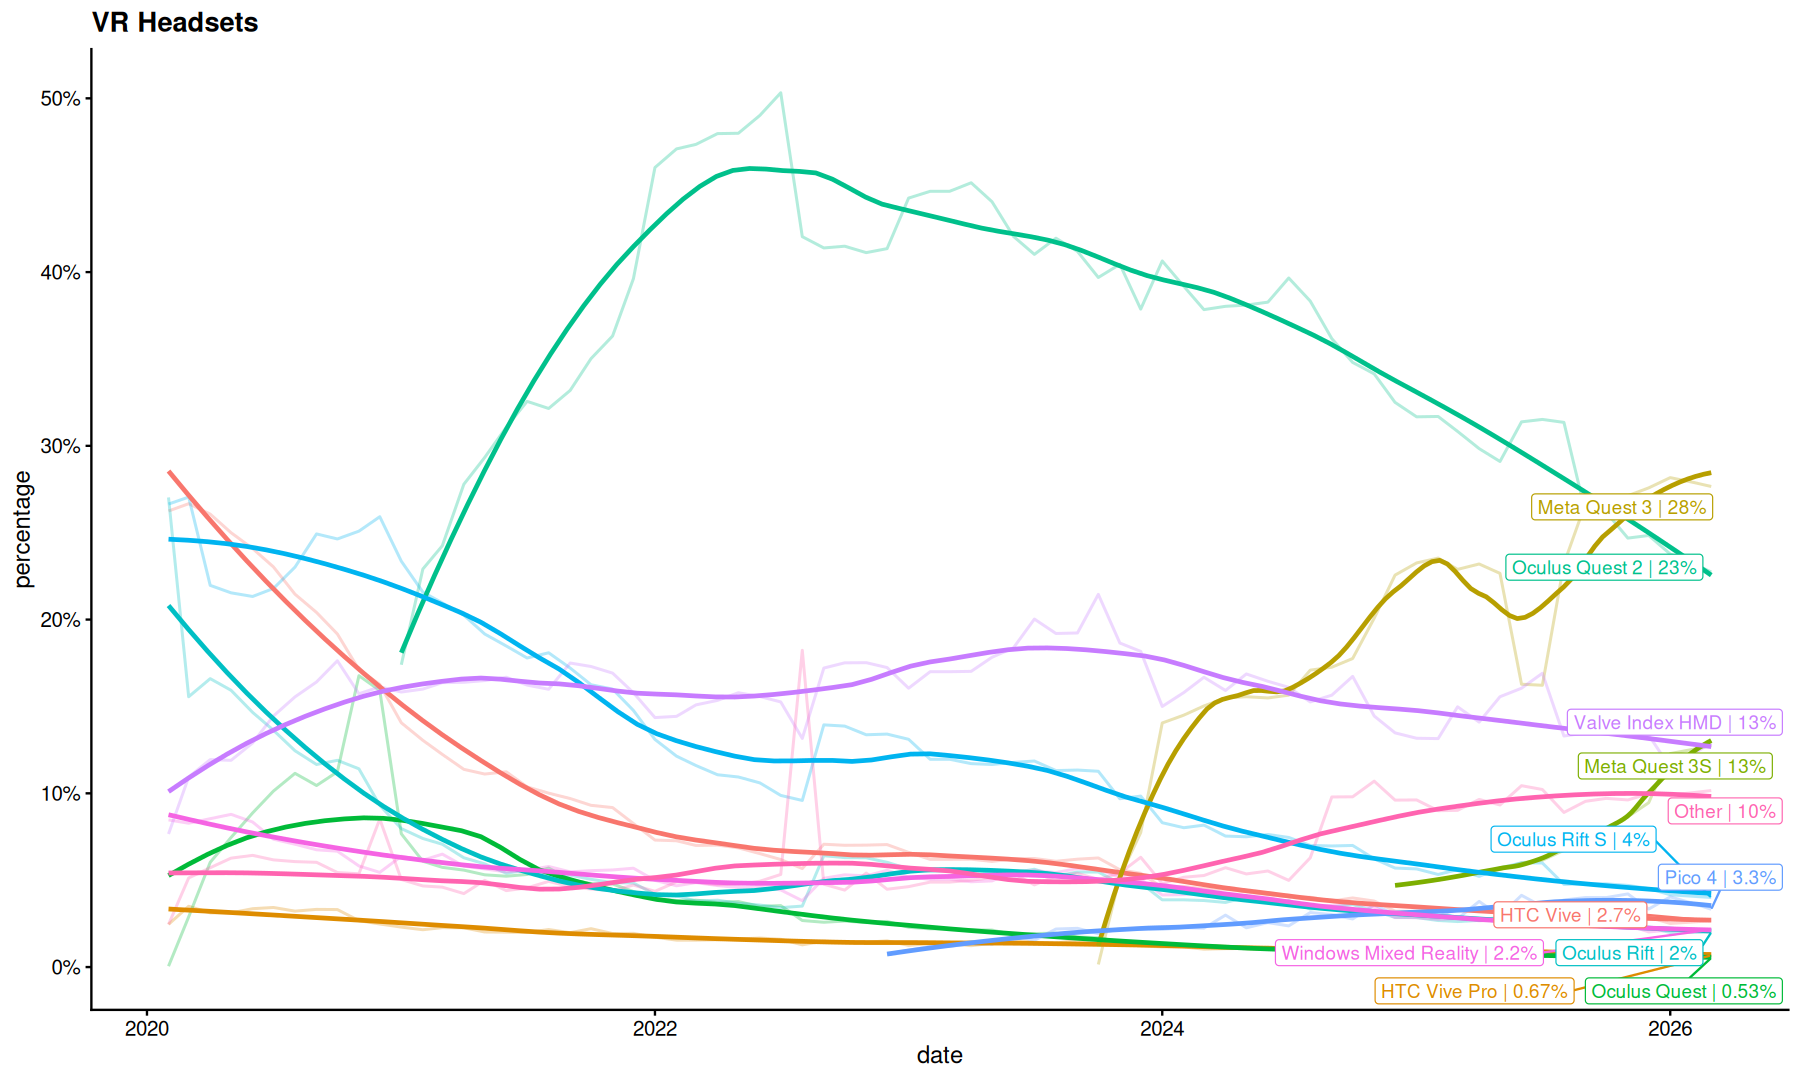

In [30]:
filter(df, grepl('VR ', category)) |>
filter(date > ymd('2020-01-01')) |>
mutate(
    name2=fct_lump_prop(name, w=percentage, prop=0.01)
) |>
summarize(
    percentage=sum(percentage),
    .by=c(date, name2)
) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %.2g%%', name2, percentage*100), NA), .by=name2) |>
ggplot(aes(x=date, y=percentage, color=name2)) +
geom_line(alpha=0.3) +
geom_smooth(se=F, span=0.5, linewidth=1) +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
labs(title='VR Headsets') +
guides(color='none') +
scale_y_continuous(label=percent_format())

## Other settings

Warning message:
"Removed 2718 rows containing missing values or values outside the scale range (`geom_label_repel()`)."


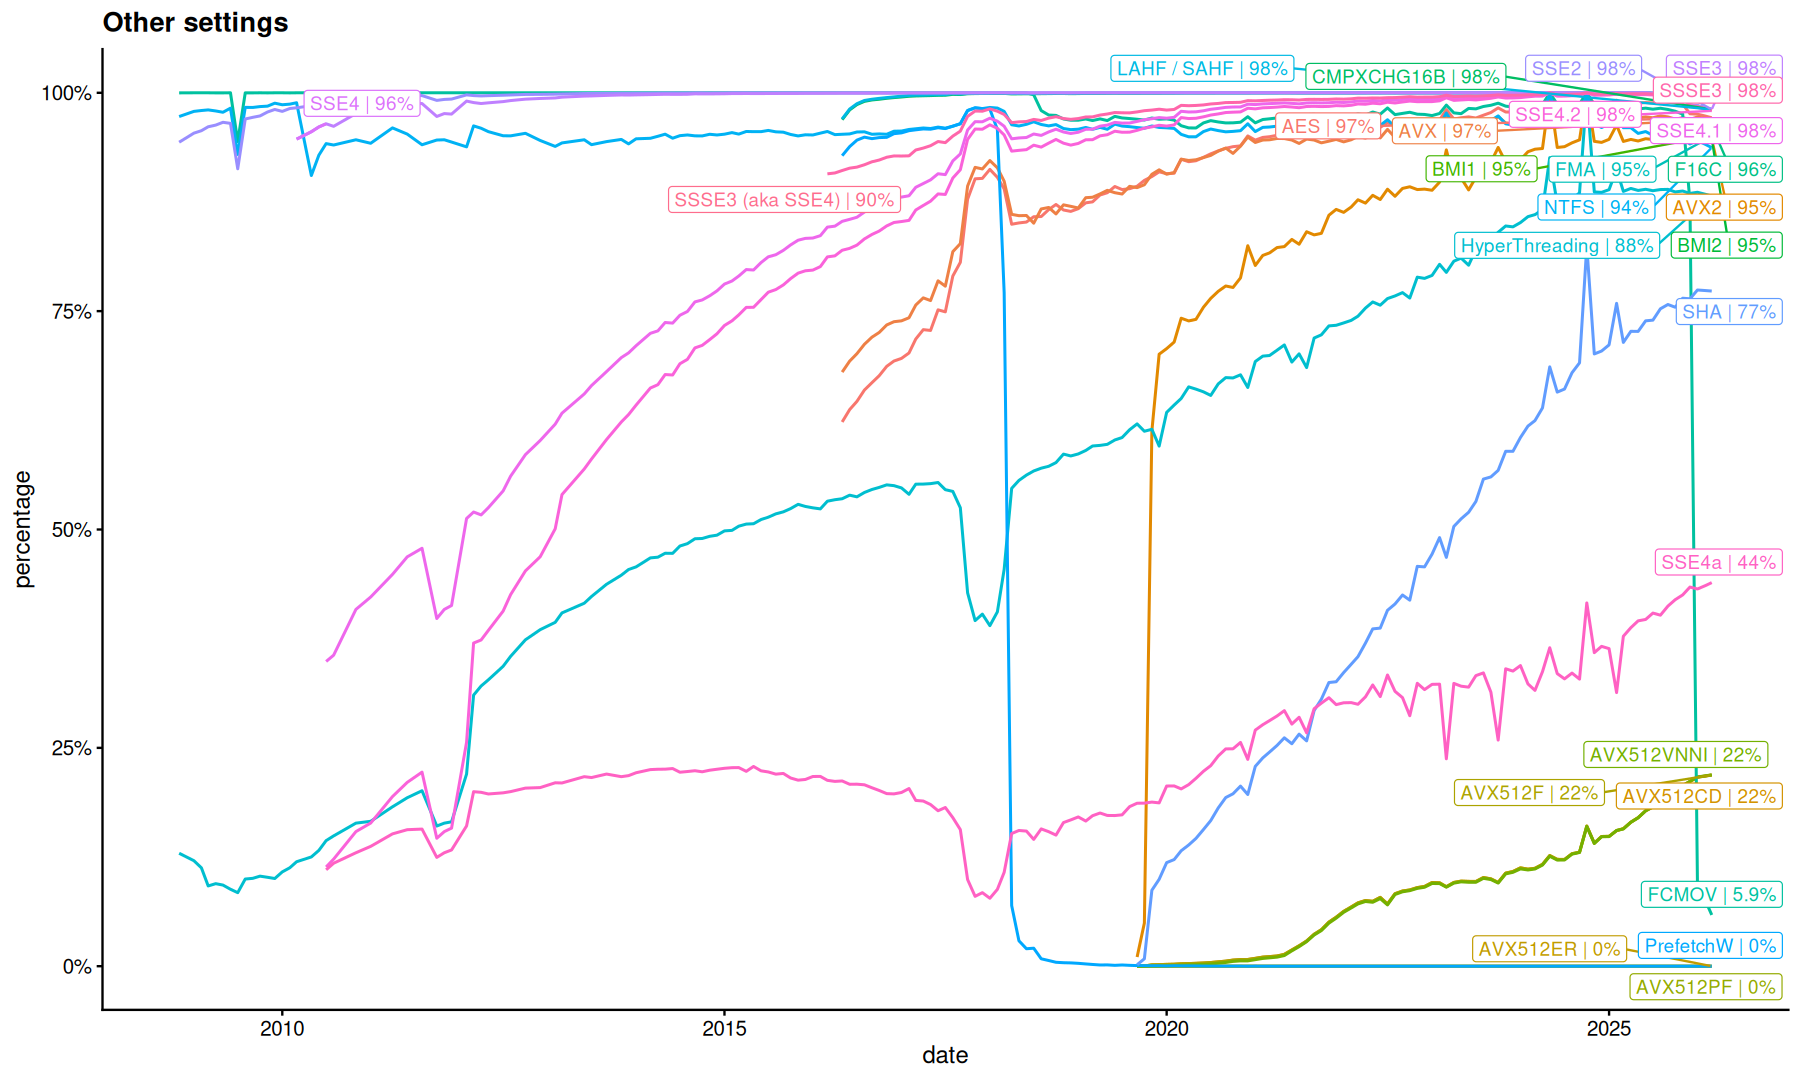

In [31]:
filter(df, grepl('Other', category)) |>
mutate(percentage=pmin(percentage, 1)) |>
mutate(label=ifelse(date==max(date, na.rm=T), sprintf('%s | %.2g%%', name, percentage*100), NA), .by=name) |>
ggplot(aes(x=date, y=percentage, color=name)) +
geom_line() +
guides(color='none') +
geom_label_repel(aes(label=label), max.overlaps = Inf) +
labs(title='Other settings') +
scale_y_continuous(label=percent_format())